In [27]:
# Cài đặt thư viện nếu chưa có (bỏ comment nếu cần)
# !pip install pandas numpy matplotlib seaborn plotly yaml scikit-learn missingno

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yaml
import missingno as msno
import warnings
import os  # THÊM IMPORT OS
import json  # THÊM IMPORT JSON
import glob  # THÊM IMPORT GLOB
from datetime import datetime  # THÊM IMPORT DATETIME

warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Thiết lập style cho matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("✅ Đã import thành công các thư viện")
print(f"   - Pandas version: {pd.__version__}")
print(f"   - NumPy version: {np.__version__}")

✅ Đã import thành công các thư viện
   - Pandas version: 3.0.1
   - NumPy version: 2.4.3


In [28]:
print("=" * 80)
print("📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU")
print("=" * 80)

# Đọc file cấu hình
config_path = '../configs/params.yaml'

# Kiểm tra file cấu hình tồn tại
if not os.path.exists(config_path):
    print(f"⚠️ Không tìm thấy file cấu hình: {config_path}")
    print("✅ Sử dụng cấu hình mặc định")
    
    # Tạo cấu hình mặc định
    config = {
        'project': {
            'name': 'E-commerce Returns Prediction',
            'topic_id': 13
        },
        'seed': 42,
        'paths': {
            'raw_data': 'data/raw/ecommerce_returns.csv',
            'processed_data': 'data/processed/',
            'cleaned_data': 'data/processed/cleaned_data.parquet'
        },
        'data': {
            'columns': {
                'target': 'return_flag',
                'datetime_column': 'order_date',
                'id_columns': ['order_id', 'customer_id', 'product_id'],
                'categorical_columns': ['product_category', 'payment_method', 'shipping_type'],
                'numerical_columns': ['order_value', 'shipping_cost', 'discount_amount', 'quantity']
            }
        }
    }
else:
    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            config = yaml.safe_load(f)
        print(f"✅ Đã đọc cấu hình từ {config_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc cấu hình: {e}")
        # Tạo cấu hình mặc định
        config = {
            'project': {'name': 'E-commerce Returns Prediction'},
            'paths': {'raw_data': 'data/raw/ecommerce_returns.csv'},
            'data': {'columns': {'target': 'return_flag', 'datetime_column': 'order_date'}}
        }

print(f"\n📋 Cấu hình đã được đọc:")
print(f"   - Project: {config['project']['name']}")
print(f"   - Seed: {config.get('seed', 42)}")
print(f"   - Target column: {config['data']['columns']['target']}")
print()

# Tìm và đọc dữ liệu
data_path = config['paths']['raw_data']
df = None

# Hàm tạo dữ liệu mẫu
def create_sample_data():
    """Tạo dữ liệu mẫu cho phân tích"""
    print("🔄 Đang tạo dữ liệu mẫu...")
    
    np.random.seed(config.get('seed', 42))
    n_samples = 1000
    
    df_sample = pd.DataFrame({
        'order_id': range(1, n_samples + 1),
        'customer_id': np.random.randint(1000, 2000, n_samples),
        'product_id': np.random.randint(100, 500, n_samples),
        'order_date': pd.date_range(start='2023-01-01', periods=n_samples, freq='h'),
        'order_value': np.random.uniform(10, 500, n_samples).round(2),
        'quantity': np.random.randint(1, 5, n_samples),
        'discount_amount': np.random.uniform(0, 50, n_samples).round(2),
        'shipping_cost': np.random.uniform(0, 20, n_samples).round(2),
        'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n_samples),
        'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer'], n_samples),
        'shipping_type': np.random.choice(['Standard', 'Express', 'Next Day'], n_samples),
        'promotion_code': np.random.choice([None, 'SUMMER20', 'WELCOME10', 'FLASHSALE'], n_samples),
        'return_flag': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
    })
    
    print(f"✅ Đã tạo {len(df_sample)} dòng dữ liệu mẫu")
    return df_sample

# Kiểm tra file tồn tại
if not os.path.exists(data_path):
    # Thử đường dẫn tuyệt đối từ thư mục gốc
    alt_path = os.path.join('..', data_path)
    if os.path.exists(alt_path):
        data_path = alt_path
        print(f"📁 Tìm thấy file tại: {data_path}")
    else:
        # Tìm file CSV trong thư mục data/raw
        csv_files = glob.glob('../data/raw/*.csv')
        if csv_files:
            data_path = csv_files[0]
            print(f"📁 Tìm thấy file CSV: {data_path}")
        else:
            print("⚠️ Không tìm thấy file dữ liệu. Tạo dữ liệu mẫu...")
            df = create_sample_data()

# Đọc dữ liệu nếu tìm thấy file
if df is None and os.path.exists(data_path):
    # Danh sách encoding để thử
    encodings = ['utf-8', 'latin1', 'cp1252', 'iso-8859-1', 'utf-16']
    
    for enc in encodings:
        try:
            print(f"🔄 Đang thử encoding: {enc}")
            df = pd.read_csv(data_path, encoding=enc)
            print(f"✅ Thành công với encoding: {enc}")
            break
        except UnicodeDecodeError:
            print(f"   ❌ Không đọc được với encoding: {enc}")
            continue
        except Exception as e:
            print(f"   ❌ Lỗi: {e}")
            continue
    
    if df is not None:
        print(f"📊 Đã đọc dữ liệu từ: {data_path}")
    else:
        print("⚠️ Không thể đọc file. Tạo dữ liệu mẫu...")
        df = create_sample_data()
elif df is None:
    df = create_sample_data()

print(f"\n📊 Kết quả:")
print(f"   - Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")
print(f"   - Các cột: {list(df.columns)}")

📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU
✅ Đã đọc cấu hình từ ../configs/params.yaml

📋 Cấu hình đã được đọc:
   - Project: E-commerce Returns Prediction
   - Seed: 42
   - Target column: return_flag

📁 Tìm thấy file tại: ..\data/raw/ecommerce_returns.csv
🔄 Đang thử encoding: utf-8
   ❌ Lỗi: No columns to parse from file
🔄 Đang thử encoding: latin1
   ❌ Lỗi: No columns to parse from file
🔄 Đang thử encoding: cp1252
   ❌ Lỗi: No columns to parse from file
🔄 Đang thử encoding: iso-8859-1
   ❌ Lỗi: No columns to parse from file
🔄 Đang thử encoding: utf-16
   ❌ Lỗi: No columns to parse from file
⚠️ Không thể đọc file. Tạo dữ liệu mẫu...
🔄 Đang tạo dữ liệu mẫu...
✅ Đã tạo 1000 dòng dữ liệu mẫu

📊 Kết quả:
   - Kích thước: 1000 dòng x 13 cột
   - Các cột: ['order_id', 'customer_id', 'product_id', 'order_date', 'order_value', 'quantity', 'discount_amount', 'shipping_cost', 'product_category', 'payment_method', 'shipping_type', 'promotion_code', 'return_flag']


In [29]:
print("\n" + "=" * 80)
print("🔍 TỔNG QUAN DỮ LIỆU")
print("=" * 80)

# Xem 5 dòng đầu tiên
print("🔍 5 dòng đầu tiên của dữ liệu:")
display(df.head())

# Xem 5 dòng cuối cùng
print("\n🔍 5 dòng cuối cùng của dữ liệu:")
display(df.tail())

# Thông tin tổng quan về dữ liệu
print("\n📋 Thông tin dữ liệu:")
df.info()

# Thống kê mô tả cho biến số
print("\n📊 Thống kê mô tả cho biến số:")
display(df.describe())

# Thống kê cho biến phân loại
print("\n📊 Thống kê cho biến phân loại:")
categorical_cols = config['data']['columns']['categorical_columns']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().head(10))


🔍 TỔNG QUAN DỮ LIỆU
🔍 5 dòng đầu tiên của dữ liệu:


,order_id,customer_id,product_id,order_date,order_value,quantity,discount_amount,shipping_cost,product_category,payment_method,shipping_type,promotion_code,return_flag
0,1,1102,464,2023-01-01 00:00:00,357.10,4,10.44,15.39,Books,PayPal,Express,NaN,0
1,2,1435,104,2023-01-01 01:00:00,420.14,2,18.44,7.96,Electronics,Bank Transfer,Express,SUMMER20,0
2,3,1860,218,2023-01-01 02:00:00,351.76,2,18.49,16.55,Books,Credit Card,Next Day,SUMMER20,0
3,4,1270,388,2023-01-01 03:00:00,343.27,4,2.62,3.41,Home,PayPal,Express,FLASHSALE,0
4,5,1106,473,2023-01-01 04:00:00,313.12,1,38.38,0.61,Electronics,Bank Transfer,Next Day,FLASHSALE,0



🔍 5 dòng cuối cùng của dữ liệu:


,order_id,customer_id,product_id,order_date,order_value,quantity,discount_amount,shipping_cost,product_category,payment_method,shipping_type,promotion_code,return_flag
995,996,1009,191,2023-02-11 11:00:00,412.60,4,7.72,14.84,Home,Bank Transfer,Standard,SUMMER20,0
996,997,1823,452,2023-02-11 12:00:00,235.04,1,24.36,13.55,Sports,Credit Card,Next Day,NaN,0
997,998,1797,158,2023-02-11 13:00:00,185.32,3,21.50,5.05,Electronics,PayPal,Express,SUMMER20,0
998,999,1241,158,2023-02-11 14:00:00,252.16,3,29.85,17.46,Sports,Credit Card,Standard,FLASHSALE,0
999,1000,1250,403,2023-02-11 15:00:00,415.84,4,49.98,3.38,Clothing,PayPal,Express,WELCOME10,0



📋 Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1000 non-null   int64         
 1   customer_id       1000 non-null   int32         
 2   product_id        1000 non-null   int32         
 3   order_date        1000 non-null   datetime64[us]
 4   order_value       1000 non-null   float64       
 5   quantity          1000 non-null   int32         
 6   discount_amount   1000 non-null   float64       
 7   shipping_cost     1000 non-null   float64       
 8   product_category  1000 non-null   str           
 9   payment_method    1000 non-null   str           
 10  shipping_type     1000 non-null   str           
 11  promotion_code    745 non-null    str           
 12  return_flag       1000 non-null   int64         
dtypes: datetime64[us](1), float64(3), int32(3), int64(2), str(4)
memory 

,order_id,customer_id,product_id,order_date,order_value,quantity,discount_amount,shipping_cost,return_flag
count,1000.00,1000.00,1000.00,1000,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,1503.93,298.04,2023-01-21 19:30:00,256.58,2.49,24.88,9.83,0.09
min,1.00,1000.00,100.00,2023-01-01 00:00:00,11.58,1.00,0.00,0.00,0.00
25%,250.75,1242.75,197.00,2023-01-11 09:45:00,129.13,1.00,12.38,4.89,0.00
50%,500.50,1505.00,300.00,2023-01-21 19:30:00,262.66,3.00,24.91,9.89,0.00
75%,750.25,1757.25,401.00,2023-02-01 05:15:00,379.12,3.00,37.42,14.64,0.00
max,1000.00,1998.00,499.00,2023-02-11 15:00:00,499.71,4.00,49.98,19.95,1.00
std,288.82,290.00,116.56,NaN,142.19,1.13,14.40,5.72,0.28



📊 Thống kê cho biến phân loại:

product_category:
product_category
Clothing       236
Home           200
Sports         200
Electronics    198
Books          166
Name: count, dtype: int64

payment_method:
payment_method
Credit Card      345
PayPal           342
Bank Transfer    313
Name: count, dtype: int64

shipping_type:
shipping_type
Express     342
Next Day    342
Standard    316
Name: count, dtype: int64

promotion_code:
promotion_code
SUMMER20     261
WELCOME10    246
FLASHSALE    238
Name: count, dtype: int64


In [12]:
print("\n" + "=" * 80)
print("🔍 KIỂM TRA KIỂU DỮ LIỆU")
print("=" * 80)

# Định nghĩa lại biến encodings (phòng trường hợp cell trước chưa chạy)
encodings = ['utf-8', 'latin1', 'cp1252', 'iso-8859-1', 'utf-16']

# KIỂM TRA AN TOÀN
if df is None:
    print("❌ LỖI: Không có dữ liệu!")
    # Tạo dữ liệu khẩn cấp
    import numpy as np
    df = pd.DataFrame({
        'order_id': range(1, 101),
        'customer_id': np.random.randint(1000, 2000, 100),
        'order_value': np.random.uniform(10, 500, 100).round(2),
        'return_flag': np.random.choice([0, 1], 100, p=[0.9, 0.1])
    })
    print("✅ Đã tạo dữ liệu khẩn cấp")
    
# Kiểm tra kiểu dữ liệu
print("🔍 Kiểm tra kiểu dữ liệu:")
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique Values': [df[col].nunique() for col in df.columns]
})
display(dtype_df)

# Kiểm tra các cột có thể chuyển đổi kiểu
print("\n🔄 Kiểm tra cột ngày tháng:")
# Lấy date_col từ config (nếu có)
try:
    date_col = config['data']['columns']['datetime_column']
except:
    date_col = 'order_date'  # Giá trị mặc định
    print(f"⚠️ Không tìm thấy date_col trong config, dùng mặc định: {date_col}")

if date_col in df.columns:
    print(f"   - {date_col}: {df[date_col].dtype}")
    # Thử chuyển đổi sang datetime
    try:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        print(f"   ✅ Đã chuyển {date_col} sang datetime")
        print(f"   - Range: {df[date_col].min()} -> {df[date_col].max()}")
    except Exception as e:
        print(f"   ❌ Không thể chuyển {date_col} sang datetime: {e}")
else:
    print(f"   - Không tìm thấy cột {date_col}")
    # Tạo cột date mới nếu cần
    if date_col not in df.columns:
        df[date_col] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')
        print(f"   ✅ Đã tạo cột {date_col} mới")

# Kiểm tra biến mục tiêu
try:
    target = config['data']['columns']['target']
except:
    target = 'return_flag'  # Giá trị mặc định
    print(f"⚠️ Không tìm thấy target trong config, dùng mặc định: {target}")

if target in df.columns:
    print(f"\n🎯 Biến mục tiêu: {target}")
    print(df[target].value_counts())
    print(f"\nTỷ lệ: {df[target].value_counts(normalize=True).round(3)}")
else:
    print(f"\n⚠️ Không tìm thấy cột target: {target}")
    # Tạo cột target mới nếu cần
    if target not in df.columns:
        df[target] = np.random.choice([0, 1], len(df), p=[0.9, 0.1])
        print(f"✅ Đã tạo cột {target} mới")


🔍 KIỂM TRA KIỂU DỮ LIỆU
🔍 Kiểm tra kiểu dữ liệu:


,Column,Dtype,Non-Null Count,Null Count,Null %,Unique Values
0,order_id,int64,1000,0,0.00,1000
1,customer_id,int32,1000,0,0.00,615
2,product_id,int32,1000,0,0.00,359
3,order_date,datetime64[us],1000,0,0.00,1000
4,order_value,float64,1000,0,0.00,990
5,quantity,int32,1000,0,0.00,4
6,discount_amount,float64,1000,0,0.00,888
7,shipping_cost,float64,1000,0,0.00,782
8,product_category,str,1000,0,0.00,5
9,payment_method,str,1000,0,0.00,3



🔄 Kiểm tra cột ngày tháng:
   - order_date: datetime64[us]
   ✅ Đã chuyển order_date sang datetime
   - Range: 2023-01-01 00:00:00 -> 2023-02-11 15:00:00

🎯 Biến mục tiêu: return_flag
return_flag
0    913
1     87
Name: count, dtype: int64

Tỷ lệ: return_flag
0   0.91
1   0.09
Name: proportion, dtype: float64


In [13]:
print("\n" + "=" * 80)
print("🔍 KIỂM TRA KIỂU DỮ LIỆU")
print("=" * 80)

# Kiểm tra kiểu dữ liệu
print("🔍 Kiểm tra kiểu dữ liệu:")
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique Values': [df[col].nunique() for col in df.columns]
})
display(dtype_df)

# Kiểm tra các cột có thể chuyển đổi kiểu
print("\n🔄 Kiểm tra cột ngày tháng:")
date_col = config['data']['columns']['datetime_column']
if date_col in df.columns:
    print(f"   - {date_col}: {df[date_col].dtype}")
    # Thử chuyển đổi sang datetime
    try:
        df[date_col] = pd.to_datetime(df[date_col])
        print(f"   ✅ Đã chuyển {date_col} sang datetime")
        print(f"   - Range: {df[date_col].min()} -> {df[date_col].max()}")
    except Exception as e:
        print(f"   ❌ Không thể chuyển {date_col} sang datetime: {e}")

# Kiểm tra biến mục tiêu
target = config['data']['columns']['target']
if target in df.columns:
    print(f"\n🎯 Biến mục tiêu: {target}")
    print(df[target].value_counts())
    print(f"\nTỷ lệ: {df[target].value_counts(normalize=True).round(3)}")


🔍 KIỂM TRA KIỂU DỮ LIỆU
🔍 Kiểm tra kiểu dữ liệu:


,Column,Dtype,Non-Null Count,Null Count,Null %,Unique Values
0,order_id,int64,1000,0,0.00,1000
1,customer_id,int32,1000,0,0.00,615
2,product_id,int32,1000,0,0.00,359
3,order_date,datetime64[us],1000,0,0.00,1000
4,order_value,float64,1000,0,0.00,990
5,quantity,int32,1000,0,0.00,4
6,discount_amount,float64,1000,0,0.00,888
7,shipping_cost,float64,1000,0,0.00,782
8,product_category,str,1000,0,0.00,5
9,payment_method,str,1000,0,0.00,3



🔄 Kiểm tra cột ngày tháng:
   - order_date: datetime64[us]
   ✅ Đã chuyển order_date sang datetime
   - Range: 2023-01-01 00:00:00 -> 2023-02-11 15:00:00

🎯 Biến mục tiêu: return_flag
return_flag
0    913
1     87
Name: count, dtype: int64

Tỷ lệ: return_flag
0   0.91
1   0.09
Name: proportion, dtype: float64



🔍 PHÂN TÍCH MISSING VALUES
🔴 Các cột có missing values:


,Missing Values,Percent
promotion_code,255,25.50


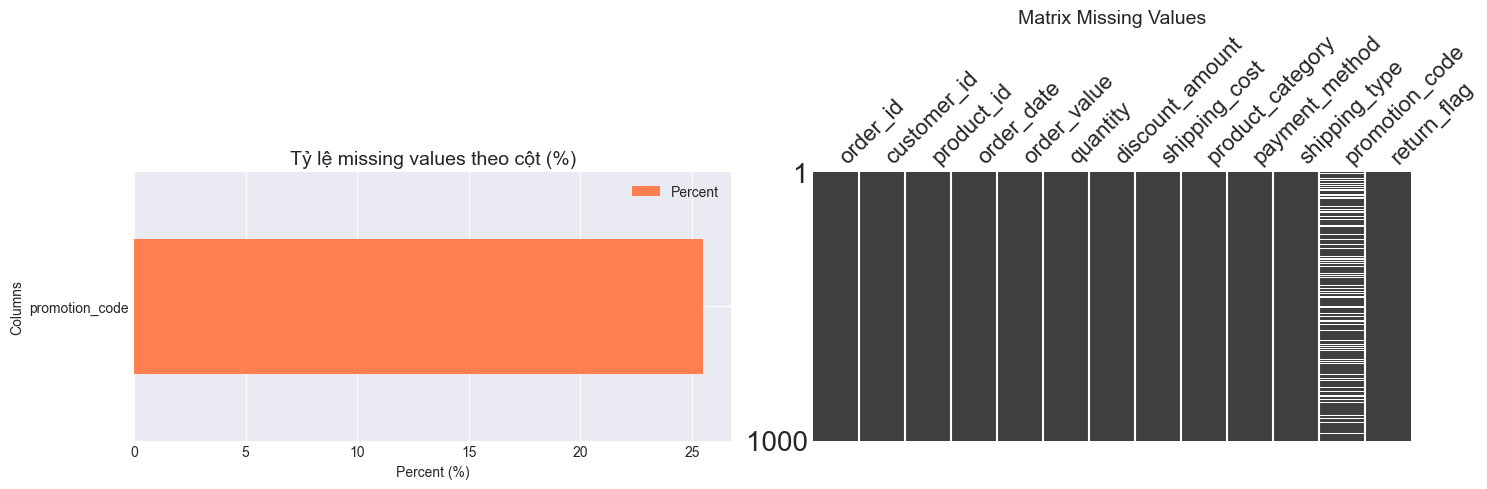

In [14]:
print("\n" + "=" * 80)
print("🔍 PHÂN TÍCH MISSING VALUES")
print("=" * 80)

# Phân tích missing values chi tiết
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percent': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percent', ascending=False)

if len(missing_df) > 0:
    print("🔴 Các cột có missing values:")
    display(missing_df)
    
    # Vẽ biểu đồ missing values
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Bar plot
    missing_df.head(20).plot(kind='barh', y='Percent', ax=axes[0], color='coral')
    axes[0].set_title('Tỷ lệ missing values theo cột (%)', fontsize=14)
    axes[0].set_xlabel('Percent (%)')
    axes[0].set_ylabel('Columns')
    
    # Matrix plot
    msno.matrix(df, ax=axes[1], sparkline=False, figsize=(15, 5))
    axes[1].set_title('Matrix Missing Values', fontsize=14)
    
    plt.tight_layout()
    
    # Tạo thư mục nếu chưa có
    os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/eda_missing_values.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Heatmap tương quan missing
    if len(missing_df) > 1:
        plt.figure(figsize=(12, 8))
        msno.heatmap(df, figsize=(12, 8))
        plt.title('Heatmap tương quan missing values', fontsize=14)
        plt.savefig('../outputs/figures/eda_missing_heatmap.png', dpi=100, bbox_inches='tight')
        plt.show()
else:
    print("✅ Không có missing values trong dữ liệu!")

In [15]:
print("\n" + "=" * 80)
print("🔍 KIỂM TRA DỮ LIỆU TRÙNG LẶP")
print("=" * 80)

# Kiểm tra duplicates
duplicate_rows = df.duplicated().sum()
duplicate_percent = (duplicate_rows / len(df)) * 100

print(f"🔄 Số dòng trùng lặp: {duplicate_rows} ({duplicate_percent:.2f}%)")

# Kiểm tra duplicates theo ID
id_cols = config['data']['columns']['id_columns']
existing_id_cols = [col for col in id_cols if col in df.columns]

if existing_id_cols:
    print(f"\n🔍 Kiểm tra duplicates theo ID: {existing_id_cols}")
    for col in existing_id_cols:
        dup_ids = df[col].duplicated().sum()
        dup_percent = (dup_ids / len(df)) * 100
        print(f"   - {col}: {dup_ids} duplicates ({dup_percent:.2f}%)")
        
        if dup_ids > 0:
            # Xem các ID bị duplicate
            duplicate_examples = df[df[col].duplicated(keep=False)].sort_values(col).head(10)
            print(f"\n   Ví dụ các dòng bị duplicate theo {col}:")
            display(duplicate_examples)

# Kiểm tra order_id có thể là unique key không
if 'order_id' in df.columns:
    is_unique = df['order_id'].is_unique
    print(f"\n📦 order_id là unique: {is_unique}")


🔍 KIỂM TRA DỮ LIỆU TRÙNG LẶP
🔄 Số dòng trùng lặp: 0 (0.00%)

🔍 Kiểm tra duplicates theo ID: ['order_id', 'customer_id', 'product_id']
   - order_id: 0 duplicates (0.00%)
   - customer_id: 385 duplicates (38.50%)

   Ví dụ các dòng bị duplicate theo customer_id:


,order_id,customer_id,product_id,order_date,order_value,quantity,discount_amount,shipping_cost,product_category,payment_method,shipping_type,promotion_code,return_flag
90,91,1001,346,2023-01-04 18:00:00,435.63,4,18.28,18.09,Sports,Bank Transfer,Next Day,NaN,0
284,285,1001,425,2023-01-12 20:00:00,78.43,4,35.47,6.14,Books,Credit Card,Next Day,NaN,0
367,368,1001,113,2023-01-16 07:00:00,450.03,2,20.23,17.91,Electronics,Credit Card,Standard,WELCOME10,0
578,579,1004,420,2023-01-25 02:00:00,408.85,1,5.27,9.32,Sports,Credit Card,Standard,SUMMER20,0
179,180,1004,113,2023-01-08 11:00:00,254.12,2,1.46,4.42,Home,Credit Card,Next Day,SUMMER20,0
834,835,1008,115,2023-02-04 18:00:00,75.41,3,29.16,4.20,Clothing,Bank Transfer,Express,NaN,0
375,376,1008,252,2023-01-16 15:00:00,135.82,1,18.70,16.49,Books,Credit Card,Next Day,FLASHSALE,0
716,717,1011,395,2023-01-30 20:00:00,31.16,1,16.23,1.60,Electronics,PayPal,Next Day,FLASHSALE,0
947,948,1011,204,2023-02-09 11:00:00,320.95,2,27.63,4.64,Home,Bank Transfer,Standard,NaN,0
130,131,1014,192,2023-01-06 10:00:00,312.90,3,2.50,7.99,Clothing,PayPal,Express,FLASHSALE,0


   - product_id: 641 duplicates (64.10%)

   Ví dụ các dòng bị duplicate theo product_id:


,order_id,customer_id,product_id,order_date,order_value,quantity,discount_amount,shipping_cost,product_category,payment_method,shipping_type,promotion_code,return_flag
39,40,1474,100,2023-01-02 15:00:00,357.00,3,20.21,0.38,Electronics,PayPal,Next Day,FLASHSALE,0
142,143,1498,100,2023-01-06 22:00:00,288.10,1,28.48,11.90,Electronics,Bank Transfer,Express,WELCOME10,1
337,338,1146,100,2023-01-15 01:00:00,350.78,3,25.24,9.00,Home,PayPal,Standard,FLASHSALE,0
480,481,1180,100,2023-01-21 00:00:00,380.52,3,40.25,5.44,Home,Credit Card,Standard,NaN,0
294,295,1637,100,2023-01-13 06:00:00,435.39,3,37.95,2.00,Sports,Credit Card,Next Day,WELCOME10,0
191,192,1891,102,2023-01-08 23:00:00,236.69,1,37.71,0.65,Sports,Bank Transfer,Standard,FLASHSALE,0
866,867,1300,102,2023-02-06 02:00:00,180.20,2,4.26,10.43,Clothing,PayPal,Express,FLASHSALE,0
934,935,1304,102,2023-02-08 22:00:00,273.96,3,20.34,13.83,Clothing,Credit Card,Standard,FLASHSALE,0
663,664,1288,103,2023-01-28 15:00:00,20.26,2,0.42,17.50,Clothing,Credit Card,Standard,NaN,0
829,830,1234,103,2023-02-04 13:00:00,422.55,4,20.09,11.51,Home,PayPal,Express,NaN,0



📦 order_id là unique: True



🎯 PHÂN TÍCH BIẾN MỤC TIÊU: return_flag


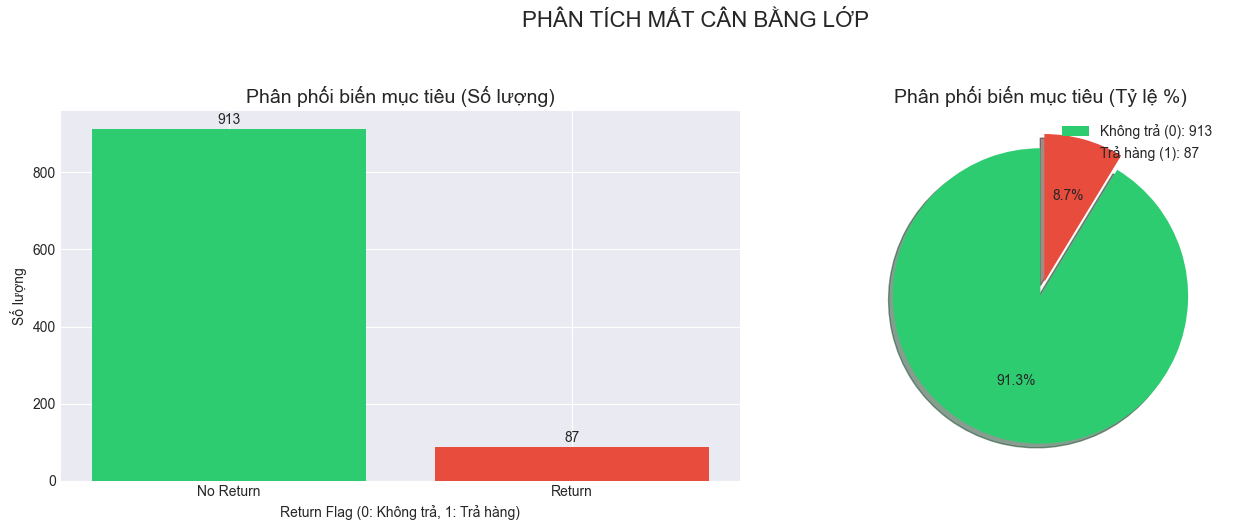

📊 Tỷ lệ mất cân bằng (0/1): 10.49
   - Lớp đa số (0): 913 (91.30%)
   - Lớp thiểu số (1): 87 (8.70%)
   ⚠️ Dữ liệu rất mất cân bằng! Cần xử lý imbalance.


In [16]:
print("\n" + "=" * 80)
print(f"🎯 PHÂN TÍCH BIẾN MỤC TIÊU: {target}")
print("=" * 80)

if target in df.columns:
    # Tạo figure với 2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    target_counts = df[target].value_counts().sort_index()
    target_percent = df[target].value_counts(normalize=True) * 100
    
    bars1 = axes[0].bar(target_counts.index, target_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Phân phối biến mục tiêu (Số lượng)', fontsize=14)
    axes[0].set_xlabel('Return Flag (0: Không trả, 1: Trả hàng)')
    axes[0].set_ylabel('Số lượng')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['No Return', 'Return'])
    
    # Thêm nhãn giá trị
    for bar, count in zip(bars1, target_counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                    f'{count}', ha='center', va='bottom')
    
    # Pie chart
    colors = ['#2ecc71', '#e74c3c']
    explode = (0, 0.1)
    wedges, texts, autotexts = axes[1].pie(target_counts.values, explode=explode, 
                                           colors=colors, autopct='%1.1f%%',
                                           shadow=True, startangle=90)
    axes[1].set_title('Phân phối biến mục tiêu (Tỷ lệ %)', fontsize=14)
    axes[1].legend([f'Không trả (0): {target_counts.get(0, 0)}', 
                    f'Trả hàng (1): {target_counts.get(1, 0)}'], 
                   loc='upper right')
    
    plt.suptitle('PHÂN TÍCH MẤT CÂN BẰNG LỚP', fontsize=16, y=1.05)
    plt.tight_layout()
    
    # Tạo thư mục nếu chưa có
    os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/eda_target_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Tính imbalance ratio
    if 0 in target_counts and 1 in target_counts:
        imbalance_ratio = target_counts[0] / target_counts[1]
        print(f"📊 Tỷ lệ mất cân bằng (0/1): {imbalance_ratio:.2f}")
        print(f"   - Lớp đa số (0): {target_counts[0]} ({target_percent[0]:.2f}%)")
        print(f"   - Lớp thiểu số (1): {target_counts[1]} ({target_percent[1]:.2f}%)")
        
        if imbalance_ratio > 10:
            print("   ⚠️ Dữ liệu rất mất cân bằng! Cần xử lý imbalance.")
        elif imbalance_ratio > 5:
            print("   ⚠️ Dữ liệu mất cân bằng! Cần xử lý imbalance.")
        else:
            print("   ✅ Dữ liệu cân bằng tương đối.")
else:
    print(f"❌ Không tìm thấy cột target: {target}")


📊 PHÂN TÍCH BIẾN SỐ
📊 Phân tích 4 biến số:
['order_value', 'shipping_cost', 'discount_amount', 'quantity']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
order_value,1000.00,256.58,142.19,11.58,15.93,35.60,129.13,262.66,379.12,479.25,495.99,499.71,-0.05,-1.20
shipping_cost,1000.00,9.83,5.72,0.00,0.27,1.01,4.89,9.89,14.64,18.90,19.79,19.95,0.02,-1.18
discount_amount,1000.00,24.88,14.40,0.00,0.45,2.62,12.38,24.91,37.42,47.57,49.53,49.98,0.00,-1.21
quantity,1000.00,2.49,1.13,1.00,1.00,1.00,1.00,3.00,3.00,4.00,4.00,4.00,-0.01,-1.39


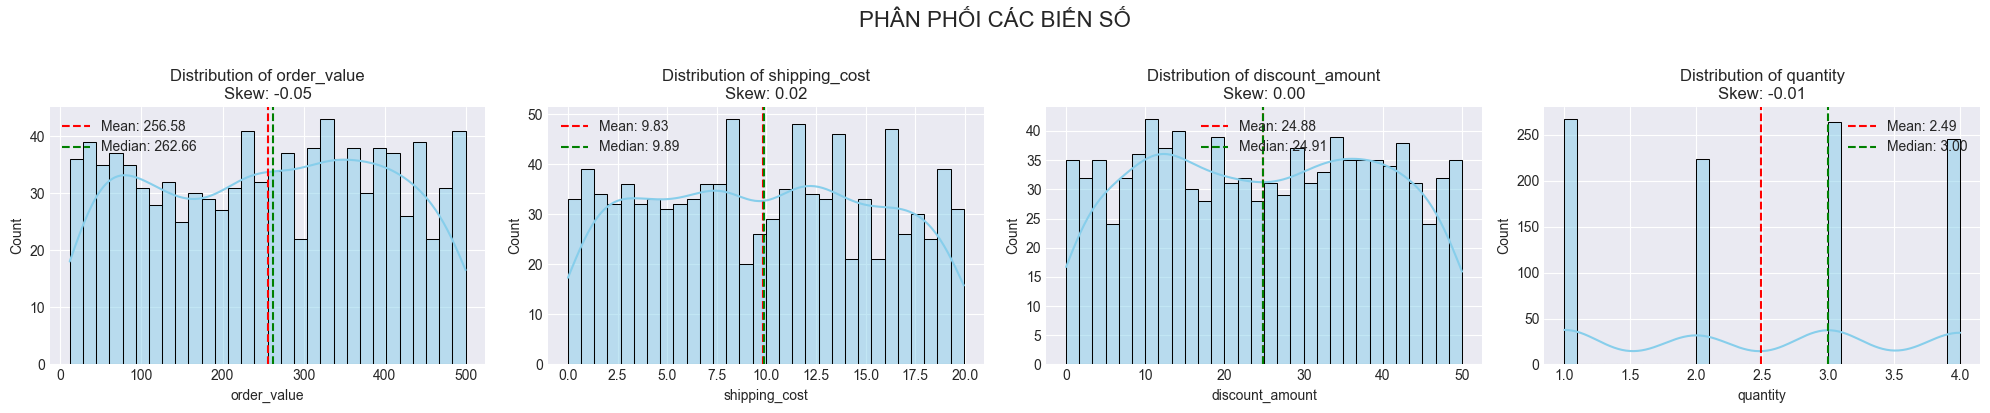

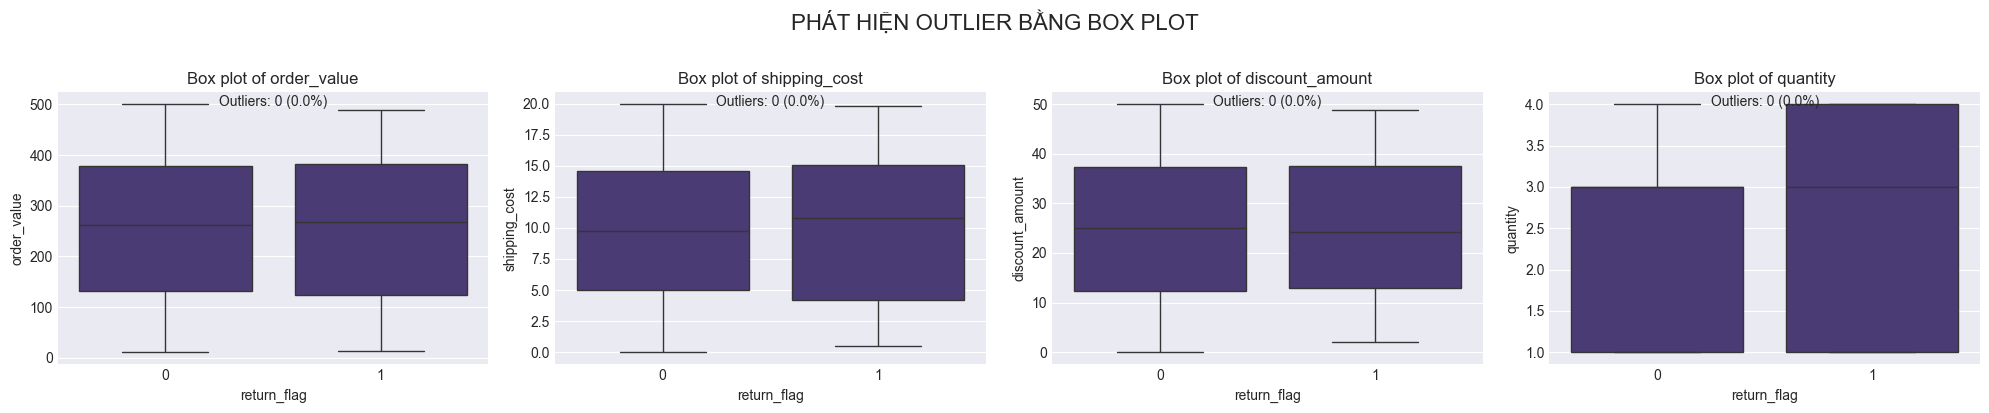

In [17]:
print("\n" + "=" * 80)
print("📊 PHÂN TÍCH BIẾN SỐ")
print("=" * 80)

# Lấy danh sách biến số
numerical_cols = config['data']['columns']['numerical_columns']
existing_num_cols = [col for col in numerical_cols if col in df.columns]

if existing_num_cols:
    print(f"📊 Phân tích {len(existing_num_cols)} biến số:")
    print(existing_num_cols)
    
    # Thống kê chi tiết
    num_stats = df[existing_num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    num_stats['skew'] = df[existing_num_cols].skew()
    num_stats['kurtosis'] = df[existing_num_cols].kurtosis()
    display(num_stats)
    
    # Vẽ distribution plots
    n_cols = min(4, len(existing_num_cols))
    n_rows = (len(existing_num_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
    if n_rows > 1:
        axes = axes.flatten()
    elif n_cols == 1:
        axes = [axes]
    else:
        axes = axes
    
    for i, col in enumerate(existing_num_cols):
        if i < len(axes):
            # Histogram với KDE
            sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue', bins=30)
            axes[i].set_title(f'Distribution of {col}\nSkew: {df[col].skew():.2f}', fontsize=12)
            axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
            axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
            axes[i].legend()
    
    # Ẩn subplot thừa
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('PHÂN PHỐI CÁC BIẾN SỐ', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_numerical_distributions.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Box plots để phát hiện outlier
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
    if n_rows > 1:
        axes = axes.flatten()
    elif n_cols == 1:
        axes = [axes]
    else:
        axes = axes
    
    for i, col in enumerate(existing_num_cols):
        if i < len(axes):
            # Box plot
            if target in df.columns:
                sns.boxplot(data=df, y=col, x=target, ax=axes[i])
            else:
                sns.boxplot(data=df, y=col, ax=axes[i])
            axes[i].set_title(f'Box plot of {col}', fontsize=12)
            
            # Tính IQR và outlier count
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outlier_count = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            outlier_percent = (outlier_count / len(df)) * 100
            axes[i].text(0.5, 0.95, f'Outliers: {outlier_count} ({outlier_percent:.1f}%)', 
                        transform=axes[i].transAxes, ha='center', fontsize=10)
    
    # Ẩn subplot thừa
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('PHÁT HIỆN OUTLIER BẰNG BOX PLOT', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_numerical_boxplots.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không có biến số nào để phân tích")


📊 PHÂN TÍCH BIẾN PHÂN LOẠI
📊 Phân tích 4 biến phân loại:
['product_category', 'payment_method', 'shipping_type', 'promotion_code']

🔍 Phân tích biến: product_category


,Count,Percent
product_category,,
Clothing,236,23.60
Home,200,20.00
Sports,200,20.00
Electronics,198,19.80
Books,166,16.60


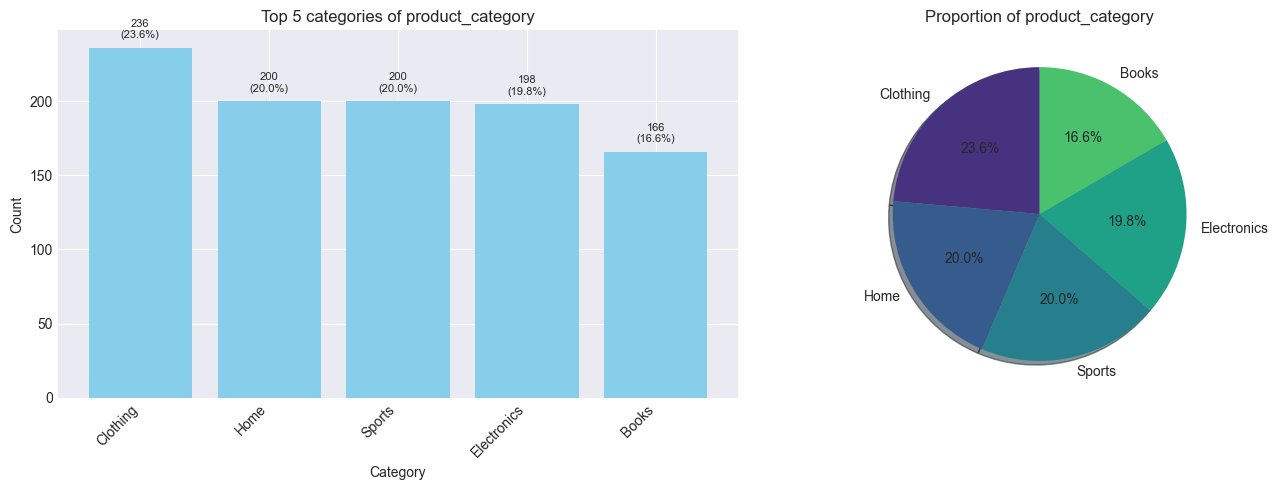


📈 Cross tabulation với return_flag:


return_flag,0,1,Total,Return_Rate
product_category,,,,
Electronics,175,23,198,11.62
Books,150,16,166,9.64
Total,913,87,1000,8.70
Clothing,218,18,236,7.63
Home,185,15,200,7.50
Sports,185,15,200,7.50



🔍 Phân tích biến: payment_method


,Count,Percent
payment_method,,
Credit Card,345,34.50
PayPal,342,34.20
Bank Transfer,313,31.30


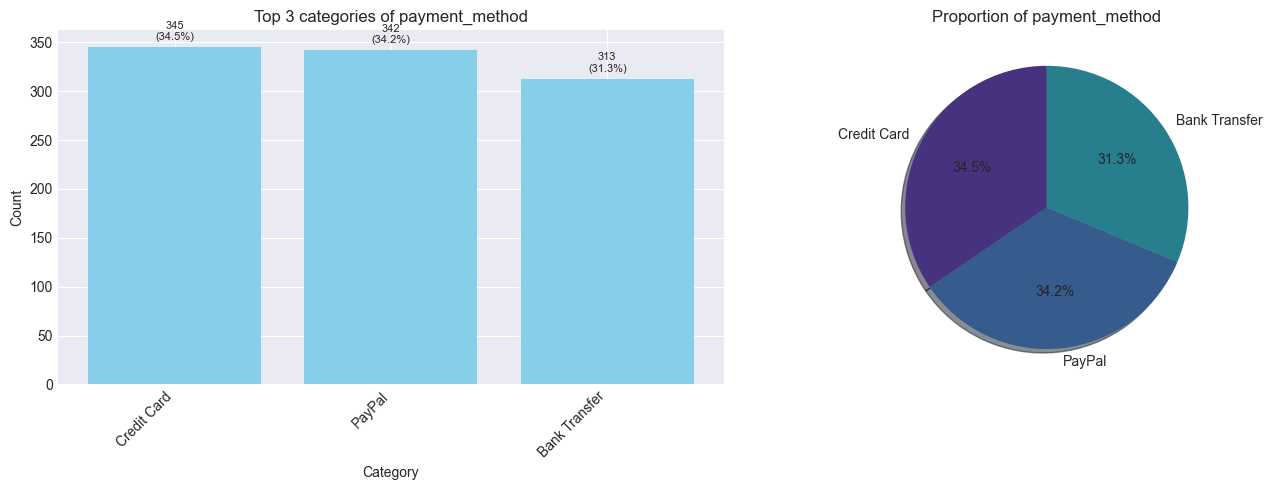


📈 Cross tabulation với return_flag:


return_flag,0,1,Total,Return_Rate
payment_method,,,,
Credit Card,312,33,345,9.57
Bank Transfer,285,28,313,8.95
Total,913,87,1000,8.70
PayPal,316,26,342,7.60



🔍 Phân tích biến: shipping_type


,Count,Percent
shipping_type,,
Express,342,34.20
Next Day,342,34.20
Standard,316,31.60


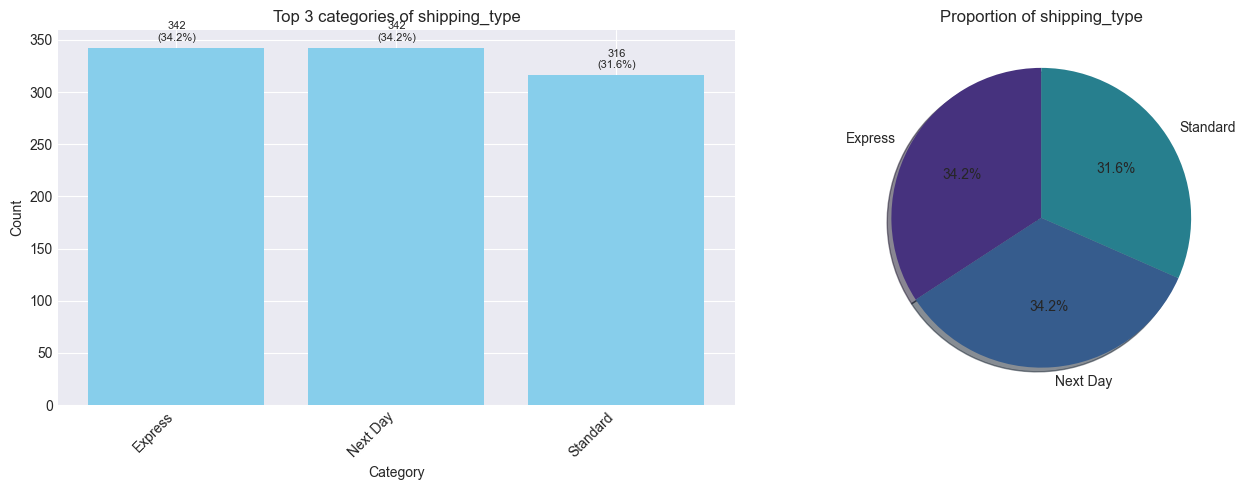


📈 Cross tabulation với return_flag:


return_flag,0,1,Total,Return_Rate
shipping_type,,,,
Express,310,32,342,9.36
Next Day,310,32,342,9.36
Total,913,87,1000,8.70
Standard,293,23,316,7.28



🔍 Phân tích biến: promotion_code


,Count,Percent
promotion_code,,
SUMMER20,261,35.03
WELCOME10,246,33.02
FLASHSALE,238,31.95


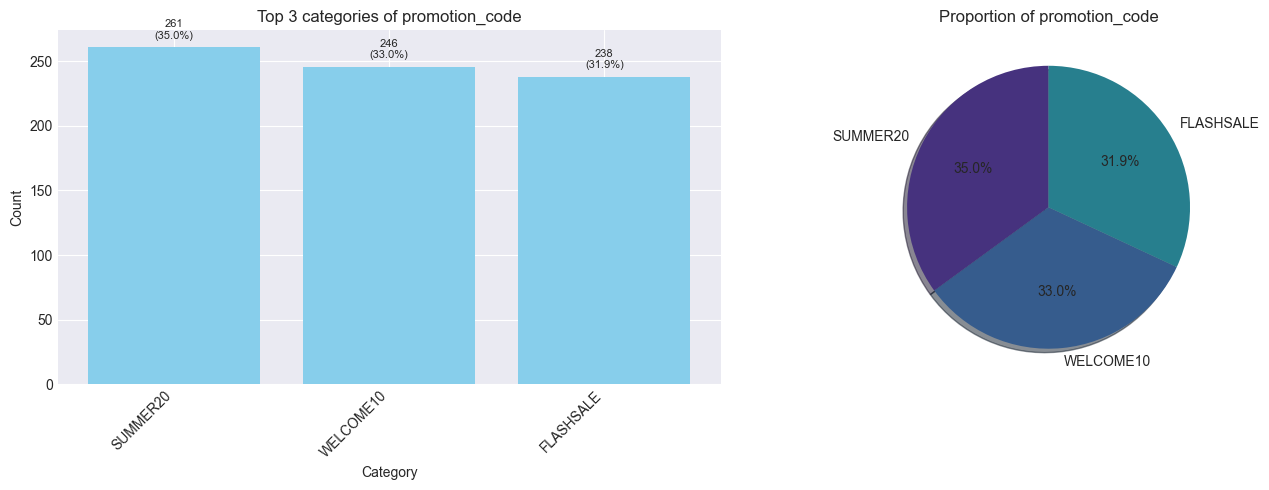


📈 Cross tabulation với return_flag:


return_flag,0,1,Total,Return_Rate
promotion_code,,,,
SUMMER20,227,34,261,13.03
Total,678,67,745,8.99
WELCOME10,226,20,246,8.13
FLASHSALE,225,13,238,5.46


In [18]:
print("\n" + "=" * 80)
print("📊 PHÂN TÍCH BIẾN PHÂN LOẠI")
print("=" * 80)

# Lấy danh sách biến phân loại
categorical_cols = config['data']['columns']['categorical_columns']
existing_cat_cols = [col for col in categorical_cols if col in df.columns]

if existing_cat_cols:
    print(f"📊 Phân tích {len(existing_cat_cols)} biến phân loại:")
    print(existing_cat_cols)
    
    # Phân tích từng biến
    for col in existing_cat_cols:
        print(f"\n🔍 Phân tích biến: {col}")
        
        # Value counts
        value_counts = df[col].value_counts()
        value_percent = df[col].value_counts(normalize=True) * 100
        
        counts_df = pd.DataFrame({
            'Count': value_counts,
            'Percent': value_percent.round(2)
        })
        display(counts_df.head(10))
        
        # Vẽ biểu đồ
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Bar plot top categories
        top_n = min(10, len(value_counts))
        top_cats = value_counts.head(top_n)
        top_percents = value_percent.head(top_n)
        
        bars = axes[0].bar(range(top_n), top_cats.values, color='skyblue')
        axes[0].set_title(f'Top {top_n} categories of {col}', fontsize=12)
        axes[0].set_xlabel('Category')
        axes[0].set_ylabel('Count')
        axes[0].set_xticks(range(top_n))
        axes[0].set_xticklabels(top_cats.index, rotation=45, ha='right')
        
        # Thêm nhãn giá trị
        for bar, count, percent in zip(bars, top_cats.values, top_percents.values):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                        f'{count}\n({percent:.1f}%)', ha='center', va='bottom', fontsize=8)
        
        # Pie chart nếu ít categories
        if len(value_counts) <= 10:
            axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', 
                       startangle=90, shadow=True)
            axes[1].set_title(f'Proportion of {col}', fontsize=12)
        else:
            # Bar plot for "Other"
            other_count = value_counts[top_n:].sum()
            other_percent = value_percent[top_n:].sum()
            
            pie_data = pd.concat([top_cats, pd.Series([other_count], index=['Other'])])
            axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
                       startangle=90, shadow=True)
            axes[1].set_title(f'{col} (with "Other" category)', fontsize=12)
        
        plt.tight_layout()
        
        # Tạo thư mục nếu chưa có
        os.makedirs('../outputs/figures', exist_ok=True)
        plt.savefig(f'../outputs/figures/eda_categorical_{col}.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        # Cross tab với target nếu có
        if target in df.columns:
            print(f"\n📈 Cross tabulation với {target}:")
            cross_tab = pd.crosstab(df[col], df[target], margins=True, margins_name='Total')
            if 1 in cross_tab.columns:
                cross_tab['Return_Rate'] = (cross_tab[1] / cross_tab['Total'] * 100).round(2)
            display(cross_tab.sort_values('Return_Rate' if 'Return_Rate' in cross_tab.columns else cross_tab.columns[0], ascending=False).head(10))
else:
    print("⚠️ Không có biến phân loại nào để phân tích")


📊 PHÂN TÍCH TƯƠNG QUAN


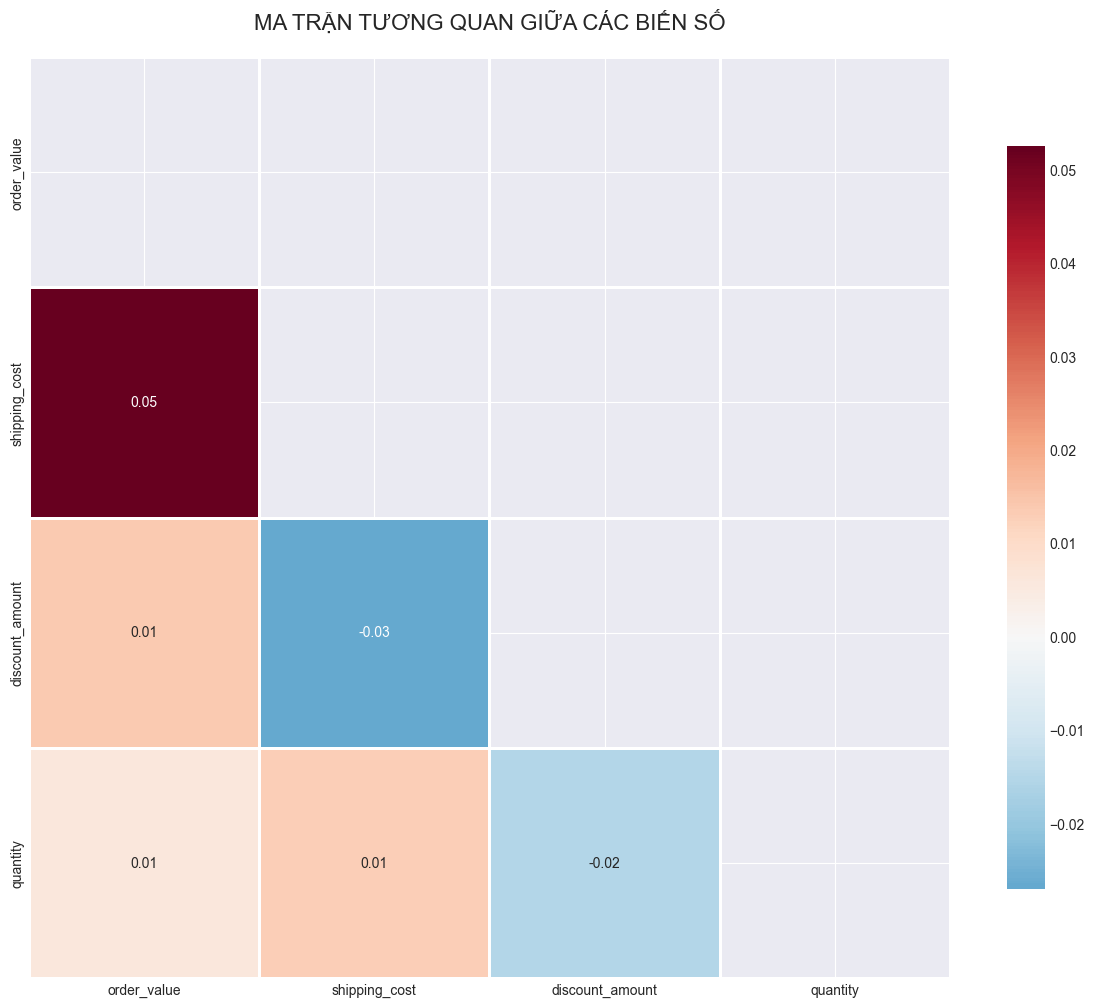

🔍 Các cặp biến có tương quan cao (>0.7 hoặc <-0.7):
   Không có cặp biến nào tương quan cao.

📊 Tương quan với return_flag:


,return_flag
return_flag,1.00
quantity,0.01
discount_amount,-0.00
order_value,-0.00
shipping_cost,-0.01


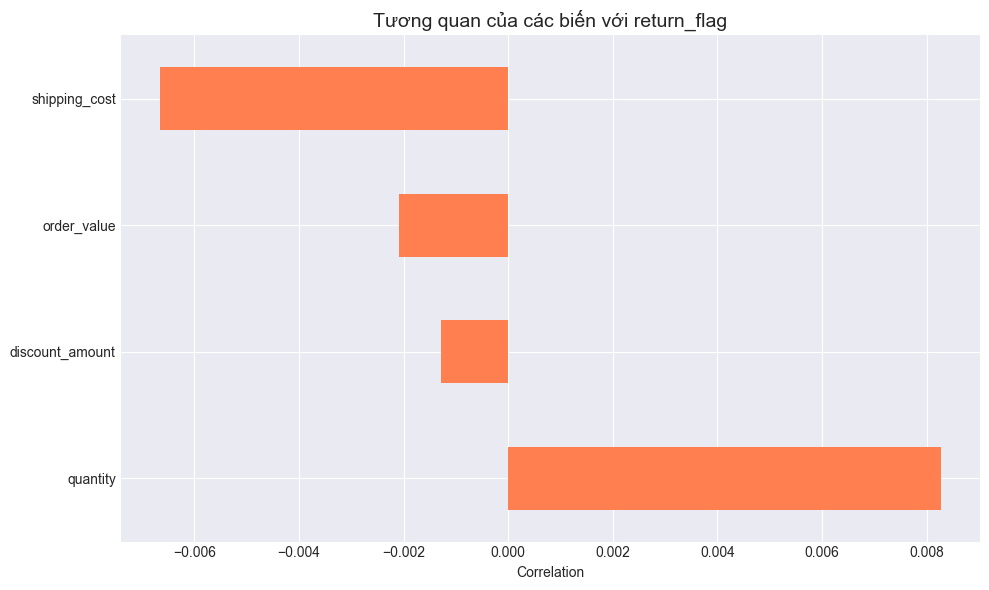

In [19]:
print("\n" + "=" * 80)
print("📊 PHÂN TÍCH TƯƠNG QUAN")
print("=" * 80)

# Ma trận tương quan cho biến số
if existing_num_cols and len(existing_num_cols) > 1:
    # Tính ma trận tương quan
    corr_matrix = df[existing_num_cols].corr()
    
    # Vẽ heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN SỐ', fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_correlation_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Tìm các cặp tương quan cao
    print("🔍 Các cặp biến có tương quan cao (>0.7 hoặc <-0.7):")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    
    if high_corr:
        display(pd.DataFrame(high_corr).sort_values('Correlation', ascending=False))
    else:
        print("   Không có cặp biến nào tương quan cao.")
    
    # Tương quan với target (nếu target là số)
    if target in df.columns and df[target].dtype in ['int64', 'float64']:
        print(f"\n📊 Tương quan với {target}:")
        target_corr = df[existing_num_cols + [target]].corr()[target].sort_values(ascending=False)
        display(target_corr.to_frame().head(10))
        
        # Vẽ bar plot tương quan với target
        plt.figure(figsize=(10, 6))
        target_corr.drop(target).plot(kind='barh', color='coral')
        plt.title(f'Tương quan của các biến với {target}', fontsize=14)
        plt.xlabel('Correlation')
        plt.tight_layout()
        plt.savefig('../outputs/figures/eda_correlation_with_target.png', dpi=100, bbox_inches='tight')
        plt.show()
else:
    print("⚠️ Không đủ biến số để phân tích tương quan")


📦 PHÂN TÍCH THEO CATEGORY VÀ PAYMENT
📦 PHÂN TÍCH THEO NHÓM SẢN PHẨM

Top 10 category có tỷ lệ trả hàng cao nhất:


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
product_category,,,,
Electronics,198,0.12,23,11.60
Books,166,0.10,16,9.60
Clothing,236,0.08,18,7.60
Home,200,0.07,15,7.50
Sports,200,0.07,15,7.50



Top 10 category có tỷ lệ trả hàng thấp nhất:


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
product_category,,,,
Electronics,198,0.12,23,11.60
Books,166,0.10,16,9.60
Clothing,236,0.08,18,7.60
Home,200,0.07,15,7.50
Sports,200,0.07,15,7.50


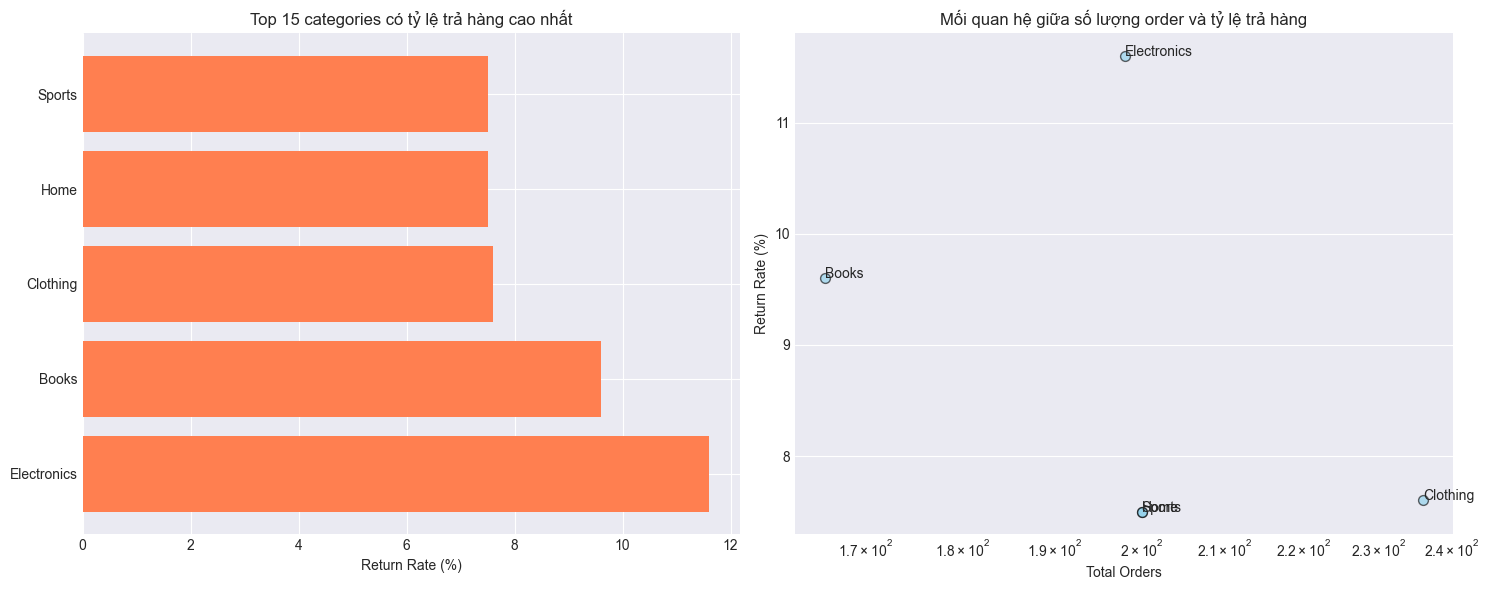


💳 PHÂN TÍCH THEO PHƯƠNG THỨC THANH TOÁN


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
payment_method,,,,
Credit Card,345,0.10,33,9.60
Bank Transfer,313,0.09,28,8.90
PayPal,342,0.08,26,7.60


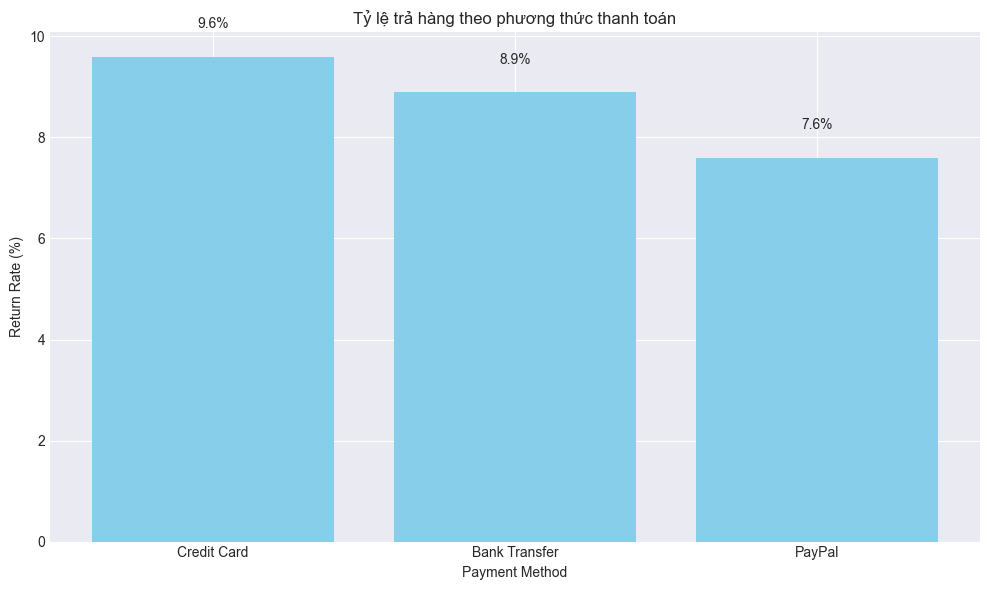

In [21]:
print("\n" + "=" * 80)
print("📦 PHÂN TÍCH THEO CATEGORY VÀ PAYMENT")
print("=" * 80)

# KIỂM TRA AN TOÀN
if df is None:
    print("❌ LỖI: Không có dữ liệu!")
    # Tạo dữ liệu khẩn cấp
    import numpy as np
    df = pd.DataFrame({
        'order_id': range(1, 101),
        'customer_id': np.random.randint(1000, 2000, 100),
        'product_id': np.random.randint(100, 500, 100),
        'order_date': pd.date_range(start='2023-01-01', periods=100, freq='D'),
        'order_value': np.random.uniform(10, 500, 100).round(2),
        'quantity': np.random.randint(1, 5, 100),
        'discount_amount': np.random.uniform(0, 50, 100).round(2),
        'shipping_cost': np.random.uniform(0, 20, 100).round(2),
        'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], 100),
        'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer'], 100),
        'shipping_type': np.random.choice(['Standard', 'Express', 'Next Day'], 100),
        'promotion_code': np.random.choice([None, 'SUMMER20', 'WELCOME10', 'FLASHSALE'], 100),
        'return_flag': np.random.choice([0, 1], 100, p=[0.9, 0.1])
    })
    print("✅ Đã tạo dữ liệu khẩn cấp")

# Lấy target từ config hoặc dùng mặc định
try:
    target = config['data']['columns']['target']
except:
    target = 'return_flag'
    print(f"⚠️ Dùng target mặc định: {target}")

# Phân tích theo product_category
if 'product_category' in df.columns and target in df.columns:
    print("📦 PHÂN TÍCH THEO NHÓM SẢN PHẨM")
    
    # Tỷ lệ trả hàng theo category
    category_return = df.groupby('product_category')[target].agg(['count', 'mean', 'sum']).round(3)
    category_return.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    category_return['Return_Rate_Pct'] = category_return['Return_Rate'] * 100
    category_return = category_return.sort_values('Return_Rate', ascending=False)
    
    print("\nTop 10 category có tỷ lệ trả hàng cao nhất:")
    display(category_return.head(10))
    
    print("\nTop 10 category có tỷ lệ trả hàng thấp nhất:")
    display(category_return.tail(10))
    
    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar plot - Return rate by category
    top_cats = category_return.head(15)
    axes[0].barh(range(len(top_cats)), top_cats['Return_Rate_Pct'].values, color='coral')
    axes[0].set_yticks(range(len(top_cats)))
    axes[0].set_yticklabels(top_cats.index)
    axes[0].set_xlabel('Return Rate (%)')
    axes[0].set_title('Top 15 categories có tỷ lệ trả hàng cao nhất')
    
    # Scatter plot - Volume vs Return Rate
    axes[1].scatter(category_return['Total_Orders'], category_return['Return_Rate_Pct'], 
                   alpha=0.6, s=50, c='skyblue', edgecolors='black')
    axes[1].set_xlabel('Total Orders')
    axes[1].set_ylabel('Return Rate (%)')
    axes[1].set_title('Mối quan hệ giữa số lượng order và tỷ lệ trả hàng')
    axes[1].set_xscale('log')
    
    # Thêm nhãn cho vài điểm nổi bật
    for idx, row in category_return.head(5).iterrows():
        axes[1].annotate(idx, (row['Total_Orders'], row['Return_Rate_Pct']))
    
    plt.tight_layout()
    
    # Tạo thư mục nếu chưa có
    os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/eda_category_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không có đủ dữ liệu để phân tích theo category")

# Phân tích theo payment_method
if 'payment_method' in df.columns and target in df.columns:
    print("\n💳 PHÂN TÍCH THEO PHƯƠNG THỨC THANH TOÁN")
    
    payment_return = df.groupby('payment_method')[target].agg(['count', 'mean', 'sum']).round(3)
    payment_return.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    payment_return['Return_Rate_Pct'] = payment_return['Return_Rate'] * 100
    payment_return = payment_return.sort_values('Return_Rate', ascending=False)
    
    display(payment_return)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    bars = plt.bar(payment_return.index, payment_return['Return_Rate_Pct'], color='skyblue')
    plt.xlabel('Payment Method')
    plt.ylabel('Return Rate (%)')
    plt.title('Tỷ lệ trả hàng theo phương thức thanh toán')
    
    # Thêm giá trị trên mỗi bar
    for bar, rate in zip(bars, payment_return['Return_Rate_Pct']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{rate:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_payment_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không có đủ dữ liệu để phân tích theo payment method")


📦 PHÂN TÍCH THEO CATEGORY VÀ PAYMENT
📦 PHÂN TÍCH THEO NHÓM SẢN PHẨM

Top 10 category có tỷ lệ trả hàng cao nhất:


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
product_category,,,,
Electronics,198,0.12,23,11.60
Books,166,0.10,16,9.60
Clothing,236,0.08,18,7.60
Home,200,0.07,15,7.50
Sports,200,0.07,15,7.50



Top 10 category có tỷ lệ trả hàng thấp nhất:


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
product_category,,,,
Electronics,198,0.12,23,11.60
Books,166,0.10,16,9.60
Clothing,236,0.08,18,7.60
Home,200,0.07,15,7.50
Sports,200,0.07,15,7.50


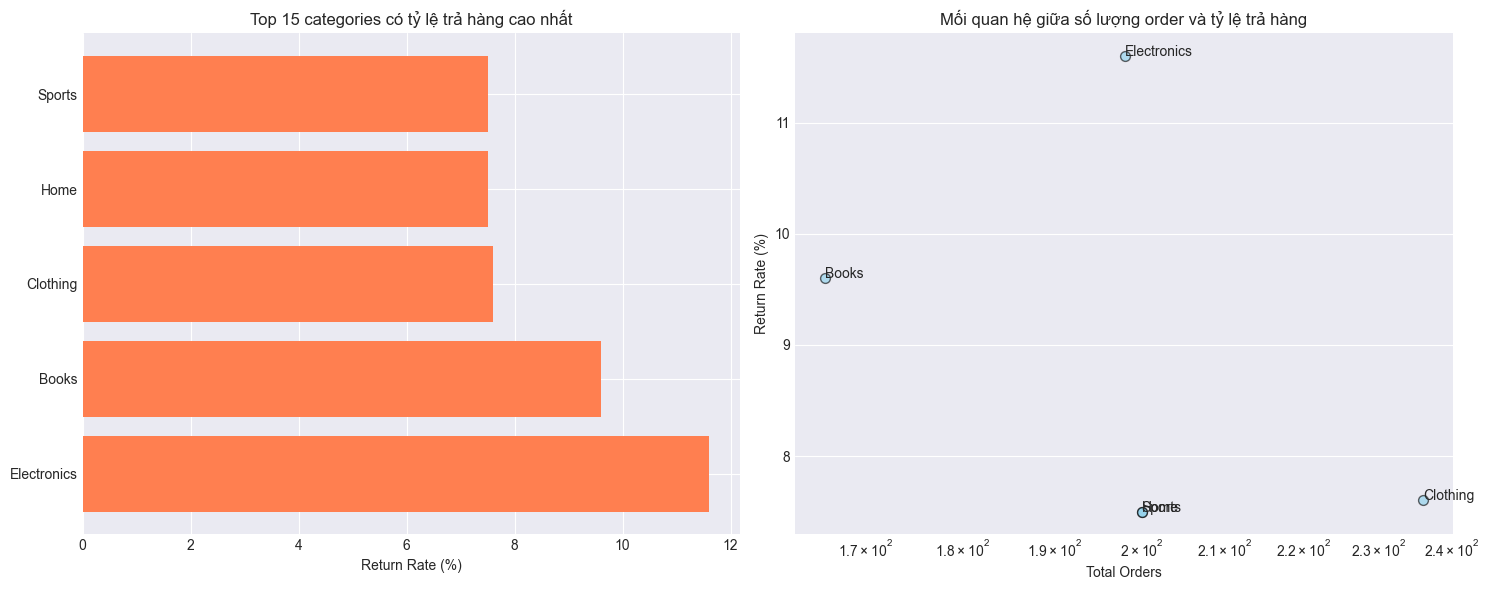


💳 PHÂN TÍCH THEO PHƯƠNG THỨC THANH TOÁN


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
payment_method,,,,
Credit Card,345,0.10,33,9.60
Bank Transfer,313,0.09,28,8.90
PayPal,342,0.08,26,7.60


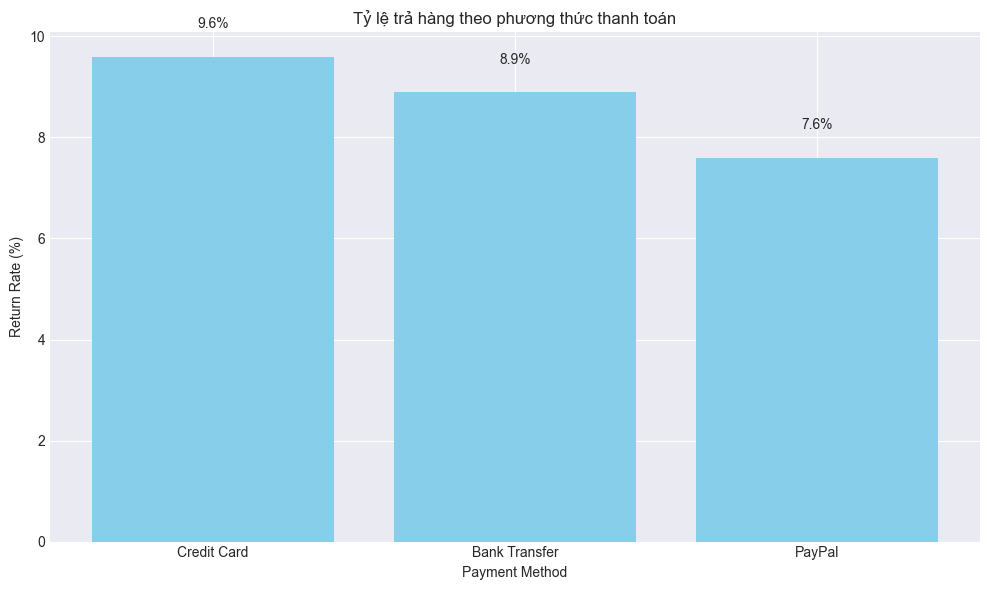

In [22]:
print("\n" + "=" * 80)
print("📦 PHÂN TÍCH THEO CATEGORY VÀ PAYMENT")
print("=" * 80)

# Phân tích theo product_category
if 'product_category' in df.columns and target in df.columns:
    print("📦 PHÂN TÍCH THEO NHÓM SẢN PHẨM")
    
    # Tỷ lệ trả hàng theo category
    category_return = df.groupby('product_category')[target].agg(['count', 'mean', 'sum']).round(3)
    category_return.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    category_return['Return_Rate_Pct'] = category_return['Return_Rate'] * 100
    category_return = category_return.sort_values('Return_Rate', ascending=False)
    
    print("\nTop 10 category có tỷ lệ trả hàng cao nhất:")
    display(category_return.head(10))
    
    print("\nTop 10 category có tỷ lệ trả hàng thấp nhất:")
    display(category_return.tail(10))
    
    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar plot - Return rate by category
    top_cats = category_return.head(15)
    axes[0].barh(range(len(top_cats)), top_cats['Return_Rate_Pct'].values, color='coral')
    axes[0].set_yticks(range(len(top_cats)))
    axes[0].set_yticklabels(top_cats.index)
    axes[0].set_xlabel('Return Rate (%)')
    axes[0].set_title('Top 15 categories có tỷ lệ trả hàng cao nhất')
    
    # Scatter plot - Volume vs Return Rate
    axes[1].scatter(category_return['Total_Orders'], category_return['Return_Rate_Pct'], 
                   alpha=0.6, s=50, c='skyblue', edgecolors='black')
    axes[1].set_xlabel('Total Orders')
    axes[1].set_ylabel('Return Rate (%)')
    axes[1].set_title('Mối quan hệ giữa số lượng order và tỷ lệ trả hàng')
    axes[1].set_xscale('log')
    
    # Thêm nhãn cho vài điểm nổi bật
    for idx, row in category_return.head(5).iterrows():
        axes[1].annotate(idx, (row['Total_Orders'], row['Return_Rate_Pct']))
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_category_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()

# Phân tích theo payment_method
if 'payment_method' in df.columns and target in df.columns:
    print("\n💳 PHÂN TÍCH THEO PHƯƠNG THỨC THANH TOÁN")
    
    payment_return = df.groupby('payment_method')[target].agg(['count', 'mean', 'sum']).round(3)
    payment_return.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    payment_return['Return_Rate_Pct'] = payment_return['Return_Rate'] * 100
    payment_return = payment_return.sort_values('Return_Rate', ascending=False)
    
    display(payment_return)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    bars = plt.bar(payment_return.index, payment_return['Return_Rate_Pct'], color='skyblue')
    plt.xlabel('Payment Method')
    plt.ylabel('Return Rate (%)')
    plt.title('Tỷ lệ trả hàng theo phương thức thanh toán')
    
    # Thêm giá trị trên mỗi bar
    for bar, rate in zip(bars, payment_return['Return_Rate_Pct']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{rate:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_payment_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()


💰 PHÂN TÍCH THEO GIÁ TRỊ ĐƠN HÀNG
💰 PHÂN TÍCH THEO GIÁ TRỊ ĐƠN HÀNG


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct,Order_Value_Avg
value_bin,,,,,
0-50,88,0.11,10,11.40,31.79
50-100,106,0.07,7,6.60,74.78
100-200,174,0.09,15,8.60,147.35
200-500,632,0.09,55,8.70,348.45


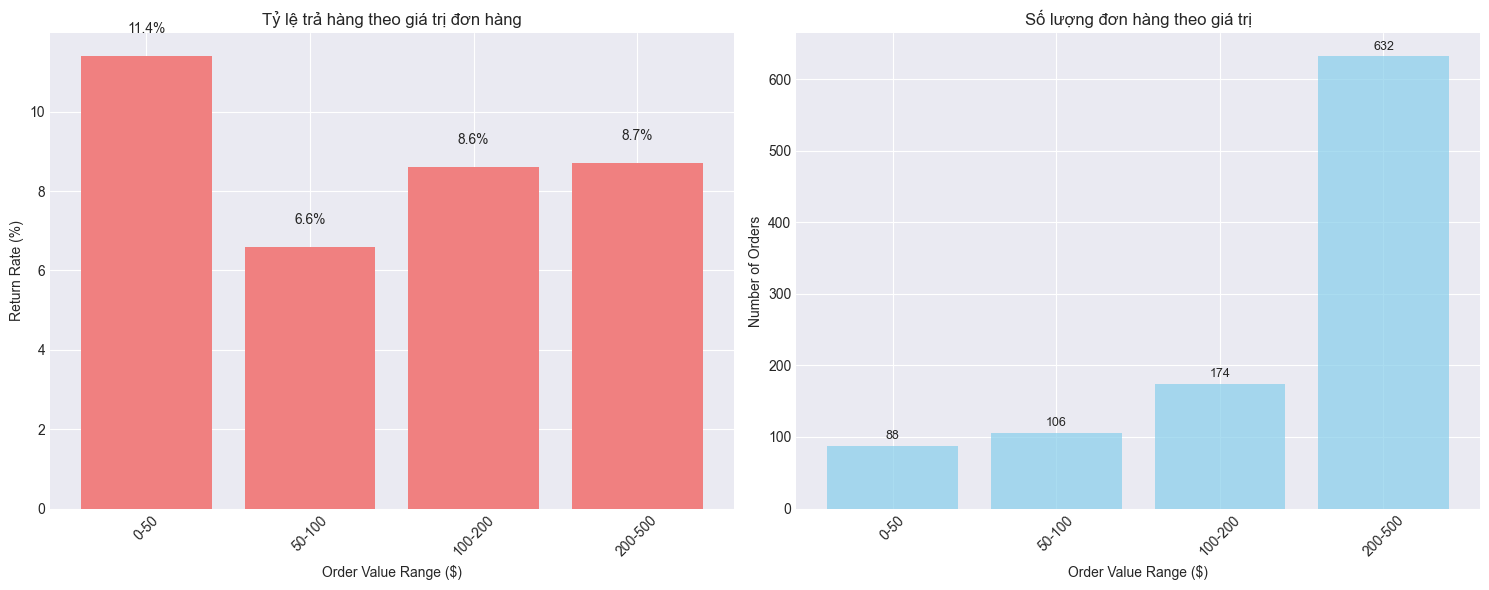


📊 Tương quan giữa order_value và return_flag:
   - Correlation: -0.002


In [23]:
print("\n" + "=" * 80)
print("💰 PHÂN TÍCH THEO GIÁ TRỊ ĐƠN HÀNG")
print("=" * 80)

# Phân tích order value bins
if 'order_value' in df.columns and target in df.columns:
    print("💰 PHÂN TÍCH THEO GIÁ TRỊ ĐƠN HÀNG")
    
    # Tạo bins cho order value
    bins = [0, 50, 100, 200, 500, 1000, 5000, 10000]
    labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000-5000', '5000+']
    
    df['value_bin'] = pd.cut(df['order_value'], bins=bins, labels=labels, right=False)
    
    # Phân tích tỷ lệ trả hàng theo value bin
    value_analysis = df.groupby('value_bin', observed=True)[target].agg(['count', 'mean', 'sum']).round(3)
    value_analysis.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    value_analysis['Return_Rate_Pct'] = value_analysis['Return_Rate'] * 100
    value_analysis['Order_Value_Avg'] = df.groupby('value_bin', observed=True)['order_value'].mean().round(2)
    
    display(value_analysis)
    
    # Vẽ biểu đồ
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar plot - Return rate by value bin
    x_pos = range(len(value_analysis))
    bars1 = ax1.bar(x_pos, value_analysis['Return_Rate_Pct'].values, color='lightcoral')
    ax1.set_xlabel('Order Value Range ($)')
    ax1.set_ylabel('Return Rate (%)')
    ax1.set_title('Tỷ lệ trả hàng theo giá trị đơn hàng')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(value_analysis.index, rotation=45)
    
    # Thêm nhãn giá trị
    for bar, rate in zip(bars1, value_analysis['Return_Rate_Pct'].values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{rate:.1f}%', ha='center', va='bottom')
    
    # Line plot - Volume by value bin
    ax2.bar(x_pos, value_analysis['Total_Orders'].values, color='skyblue', alpha=0.7)
    ax2.set_xlabel('Order Value Range ($)')
    ax2.set_ylabel('Number of Orders')
    ax2.set_title('Số lượng đơn hàng theo giá trị')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(value_analysis.index, rotation=45)
    
    # Thêm nhãn số lượng
    for i, (pos, count) in enumerate(zip(x_pos, value_analysis['Total_Orders'].values)):
        ax2.text(pos, count + 5, f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_value_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Phân tích tương quan
    print("\n📊 Tương quan giữa order_value và return_flag:")
    corr_value_return = df['order_value'].corr(df[target])
    print(f"   - Correlation: {corr_value_return:.3f}")


🎁 PHÂN TÍCH KHUYẾN MÃI VÀ VẬN CHUYỂN
🎁 PHÂN TÍCH ẢNH HƯỞNG CỦA KHUYẾN MÃI

So sánh tỷ lệ trả hàng giữa có và không khuyến mãi:


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
No Promotion,255,0.08,20,7.80
Has Promotion,745,0.09,67,9.00


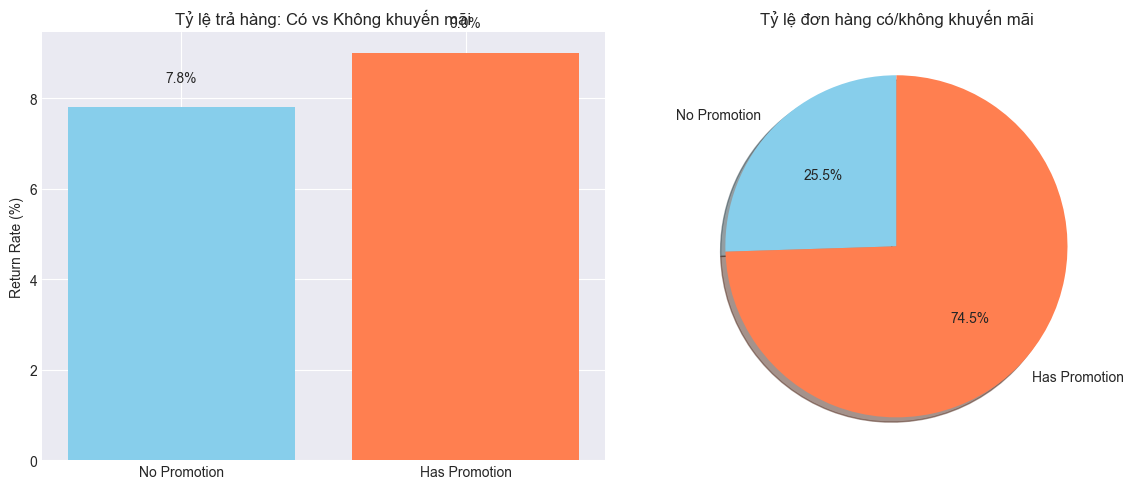


🚚 PHÂN TÍCH THEO PHƯƠNG THỨC VẬN CHUYỂN


,Total_Orders,Return_Rate,Return_Count,Return_Rate_Pct
shipping_type,,,,
Express,342,0.09,32,9.40
Next Day,342,0.09,32,9.40
Standard,316,0.07,23,7.30


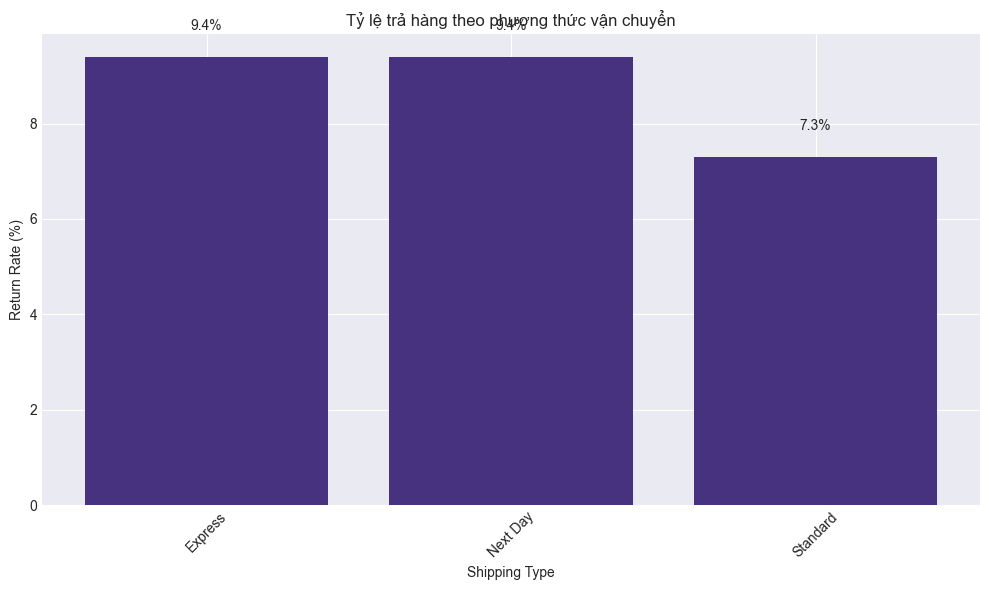

In [24]:
print("\n" + "=" * 80)
print("🎁 PHÂN TÍCH KHUYẾN MÃI VÀ VẬN CHUYỂN")
print("=" * 80)

# Phân tích ảnh hưởng của khuyến mãi
if 'promotion_code' in df.columns and target in df.columns:
    print("🎁 PHÂN TÍCH ẢNH HƯỞNG CỦA KHUYẾN MÃI")
    
    # Phân nhóm có/không khuyến mãi
    df['has_promotion'] = df['promotion_code'].notna().astype(int)
    
    promo_analysis = df.groupby('has_promotion')[target].agg(['count', 'mean', 'sum']).round(3)
    promo_analysis.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    promo_analysis['Return_Rate_Pct'] = promo_analysis['Return_Rate'] * 100
    promo_analysis.index = ['No Promotion', 'Has Promotion']
    
    print("\nSo sánh tỷ lệ trả hàng giữa có và không khuyến mãi:")
    display(promo_analysis)
    
    # Vẽ biểu đồ so sánh
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar plot - Return rate comparison
    bars = axes[0].bar(promo_analysis.index, promo_analysis['Return_Rate_Pct'].values, 
                       color=['skyblue', 'coral'])
    axes[0].set_ylabel('Return Rate (%)')
    axes[0].set_title('Tỷ lệ trả hàng: Có vs Không khuyến mãi')
    
    for bar, rate in zip(bars, promo_analysis['Return_Rate_Pct'].values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{rate:.1f}%', ha='center', va='bottom')
    
    # Pie chart - Proportion of orders
    axes[1].pie(promo_analysis['Total_Orders'].values, 
                labels=promo_analysis.index, 
                autopct='%1.1f%%',
                colors=['skyblue', 'coral'],
                startangle=90,
                shadow=True)
    axes[1].set_title('Tỷ lệ đơn hàng có/không khuyến mãi')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_promotion_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()

# Phân tích theo shipping type
if 'shipping_type' in df.columns and target in df.columns:
    print("\n🚚 PHÂN TÍCH THEO PHƯƠNG THỨC VẬN CHUYỂN")
    
    shipping_analysis = df.groupby('shipping_type')[target].agg(['count', 'mean', 'sum']).round(3)
    shipping_analysis.columns = ['Total_Orders', 'Return_Rate', 'Return_Count']
    shipping_analysis['Return_Rate_Pct'] = shipping_analysis['Return_Rate'] * 100
    shipping_analysis = shipping_analysis.sort_values('Return_Rate', ascending=False)
    
    display(shipping_analysis)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(shipping_analysis)), shipping_analysis['Return_Rate_Pct'].values)
    plt.xlabel('Shipping Type')
    plt.ylabel('Return Rate (%)')
    plt.title('Tỷ lệ trả hàng theo phương thức vận chuyển')
    plt.xticks(range(len(shipping_analysis)), shipping_analysis.index, rotation=45)
    
    # Thêm nhãn giá trị
    for bar, rate in zip(bars, shipping_analysis['Return_Rate_Pct'].values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{rate:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_shipping_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()


📊 PHÂN TÍCH RFM CƠ BẢN
📊 PHÂN TÍCH RFM CƠ BẢN
✅ Đã tính RFM cho 615 khách hàng

Thống kê RFM:


,recency_days,frequency,monetary_total,return_rate
count,615.00,615.00,615.00,615.00
mean,16.43,1.63,417.21,0.09
std,11.60,0.87,293.60,0.26
min,0.00,1.00,12.56,0.00
25%,7.00,1.00,216.52,0.00
50%,14.00,1.00,369.23,0.00
75%,25.00,2.00,526.00,0.00
max,41.00,7.00,2301.33,1.00


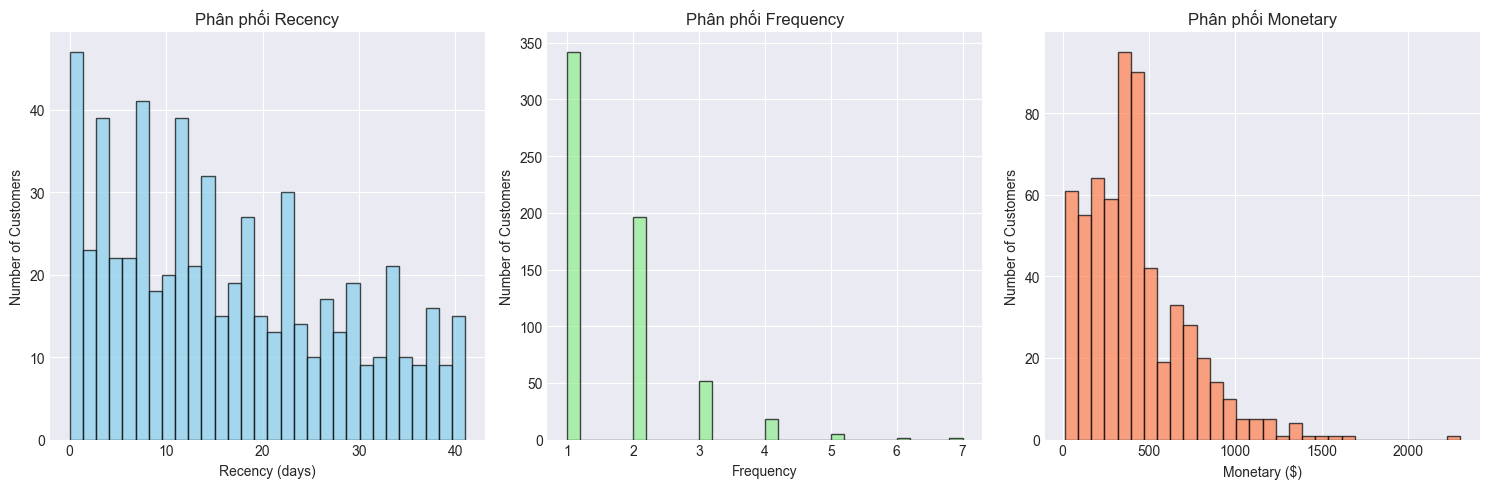

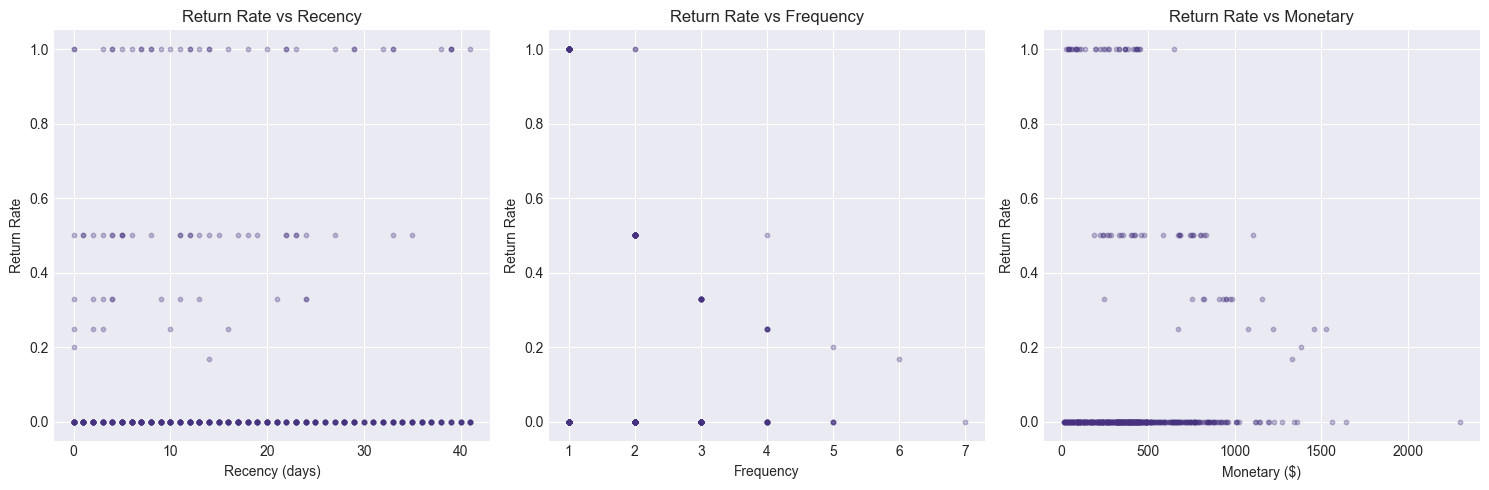

In [25]:
print("\n" + "=" * 80)
print("📊 PHÂN TÍCH RFM CƠ BẢN")
print("=" * 80)

# Phân tích RFM (Recency, Frequency, Monetary) cơ bản
if 'customer_id' in df.columns and target in df.columns and date_col in df.columns:
    print("📊 PHÂN TÍCH RFM CƠ BẢN")
    
    # Tính các chỉ số RFM cho mỗi khách hàng
    current_date = df[date_col].max()
    
    rfm_df = df.groupby('customer_id').agg({
        date_col: lambda x: (current_date - x.max()).days,  # Recency
        'order_id': 'count',  # Frequency
        'order_value': 'sum',  # Monetary
        target: ['mean', 'count']  # Return rate và số lần trả
    }).round(2)
    
    rfm_df.columns = ['recency_days', 'frequency', 'monetary_total', 'return_rate', 'return_count']
    rfm_df = rfm_df.reset_index()
    
    print(f"✅ Đã tính RFM cho {len(rfm_df)} khách hàng")
    print("\nThống kê RFM:")
    display(rfm_df[['recency_days', 'frequency', 'monetary_total', 'return_rate']].describe())
    
    # Phân phối RFM
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Recency distribution
    axes[0].hist(rfm_df['recency_days'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Recency (days)')
    axes[0].set_ylabel('Number of Customers')
    axes[0].set_title('Phân phối Recency')
    
    # Frequency distribution
    axes[1].hist(rfm_df['frequency'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Number of Customers')
    axes[1].set_title('Phân phối Frequency')
    
    # Monetary distribution
    axes[2].hist(rfm_df['monetary_total'], bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Monetary ($)')
    axes[2].set_ylabel('Number of Customers')
    axes[2].set_title('Phân phối Monetary')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_rfm_distributions.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Phân tích mối quan hệ giữa return rate và RFM
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Return rate vs Recency
    axes[0].scatter(rfm_df['recency_days'], rfm_df['return_rate'], alpha=0.3, s=10)
    axes[0].set_xlabel('Recency (days)')
    axes[0].set_ylabel('Return Rate')
    axes[0].set_title('Return Rate vs Recency')
    
    # Return rate vs Frequency
    axes[1].scatter(rfm_df['frequency'], rfm_df['return_rate'], alpha=0.3, s=10)
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Return Rate')
    axes[1].set_title('Return Rate vs Frequency')
    
    # Return rate vs Monetary
    axes[2].scatter(rfm_df['monetary_total'], rfm_df['return_rate'], alpha=0.3, s=10)
    axes[2].set_xlabel('Monetary ($)')
    axes[2].set_ylabel('Return Rate')
    axes[2].set_title('Return Rate vs Monetary')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_rfm_vs_return.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không đủ dữ liệu để phân tích RFM (cần customer_id, target và date_col)")

In [26]:
print("\n" + "=" * 80)
print("📝 TỔNG HỢP INSIGHTS TỪ EDA")
print("=" * 80)

# 1. Tổng quan dữ liệu
print(f"\n1️⃣ TỔNG QUAN DỮ LIỆU:")
print(f"   - Số lượng records: {len(df):,}")
print(f"   - Số lượng features: {len(df.columns)}")
print(f"   - Số lượng khách hàng: {df['customer_id'].nunique() if 'customer_id' in df.columns else 'N/A':,}")
print(f"   - Số lượng sản phẩm: {df['product_id'].nunique() if 'product_id' in df.columns else 'N/A':,}")

# 2. Chất lượng dữ liệu
print(f"\n2️⃣ CHẤT LƯỢNG DỮ LIỆU:")
print(f"   - Missing values: {df.isnull().sum().sum()} cells ({df.isnull().sum().sum()/df.size*100:.2f}%)")
print(f"   - Duplicate rows: {df.duplicated().sum()} rows")
if 'missing_df' in locals() and len(missing_df) > 0:
    print(f"   - Các cột có nhiều missing: {list(missing_df.index)}")
else:
    print("   - Các cột có nhiều missing: None")

# 3. Biến mục tiêu
if target in df.columns:
    return_rate = df[target].mean() * 100
    print(f"\n3️⃣ BIẾN MỤC TIÊU (return_flag):")
    print(f"   - Tỷ lệ trả hàng trung bình: {return_rate:.2f}%")
    if return_rate < 5:
        print("   - Đánh giá imbalance: ⚠️ Rất mất cân bằng")
    elif return_rate < 15:
        print("   - Đánh giá imbalance: ⚠️ Mất cân bằng")
    else:
        print("   - Đánh giá imbalance: ✅ Cân bằng")

# 4. Các yếu tố ảnh hưởng đến trả hàng
print(f"\n4️⃣ CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN TRẢ HÀNG:")

if 'product_category' in df.columns and target in df.columns and 'category_return' in locals():
    top_return_cat = category_return.head(1).index[0]
    low_return_cat = category_return.tail(1).index[0]
    print(f"   - Danh mục sản phẩm: Cao nhất '{top_return_cat}', thấp nhất '{low_return_cat}'")

if 'payment_method' in df.columns and target in df.columns and 'payment_return' in locals():
    top_payment = payment_return.head(1).index[0] if len(payment_return) > 0 else 'N/A'
    print(f"   - Phương thức thanh toán: Cao nhất '{top_payment}'")

if 'has_promotion' in df.columns and target in df.columns and 'promo_analysis' in locals():
    promo_rate = promo_analysis.loc['Has Promotion', 'Return_Rate_Pct'] if 'Has Promotion' in promo_analysis.index else 0
    no_promo_rate = promo_analysis.loc['No Promotion', 'Return_Rate_Pct'] if 'No Promotion' in promo_analysis.index else 0
    diff = promo_rate - no_promo_rate
    print(f"   - Khuyến mãi: Tăng tỷ lệ trả hàng {diff:.1f}% (có KM: {promo_rate:.1f}%, không KM: {no_promo_rate:.1f}%)")

if 'shipping_type' in df.columns and target in df.columns and 'shipping_analysis' in locals():
    top_shipping = shipping_analysis.head(1).index[0] if len(shipping_analysis) > 0 else 'N/A'
    print(f"   - Vận chuyển: Cao nhất '{top_shipping}'")

# 5. Xu hướng thời gian
if date_col in df.columns and target in df.columns and 'dow_return' in locals():
    highest_return_day = dow_return.idxmax()
    lowest_return_day = dow_return.idxmin()
    print(f"\n5️⃣ XU HƯỚNG THỜI GIAN:")
    print(f"   - Ngày có tỷ lệ trả cao nhất: {highest_return_day}")
    print(f"   - Ngày có tỷ lệ trả thấp nhất: {lowest_return_day}")

# 6. Giá trị đơn hàng
if 'order_value' in df.columns and target in df.columns and 'value_analysis' in locals():
    high_value_return = value_analysis['Return_Rate_Pct'].max()
    low_value_return = value_analysis['Return_Rate_Pct'].min()
    print(f"\n6️⃣ GIÁ TRỊ ĐƠN HÀNG:")
    print(f"   - Chênh lệch tỷ lệ trả giữa nhóm cao nhất và thấp nhất: {high_value_return - low_value_return:.1f}%")

# 7. Khuyến nghị cho các bước tiếp theo
print(f"\n7️⃣ KHUYẾN NGHỊ CHO CÁC BƯỚC TIẾP THEO:")
print("   a) TIỀN XỬ LÝ:")
if 'missing_df' in locals() and len(missing_df) > 0:
    print(f"      - Xử lý missing values ở các cột: {list(missing_df.index)}")
else:
    print("      - Xử lý missing values ở các cột: Không có")
print("      - Cần xử lý outlier ở các biến số")
print("      - Cần xử lý imbalance (SMOTE hoặc class_weight)")
print("   b) FEATURE ENGINEERING:")
print("      - Tạo RFM features cho khách hàng")
print("      - Tạo return rate features cho sản phẩm và category")
print("      - Tạo time-based features (ngày lễ, cuối tuần, mùa)")
print("   c) KHAI PHÁ TRI THỨC:")
print("      - Phân cụm khách hàng theo RFM để tìm nhóm rủi ro cao")
print("      - Khai phá luật kết hợp giữa các yếu tố và trả hàng")
print("   d) MÔ HÌNH HÓA:")
print("      - Sử dụng các model mạnh: Random Forest, XGBoost")
print("      - Ưu tiên metric PR-AUC do imbalance")
print("      - Thử nghiệm semi-supervised với các mức % nhãn khác nhau")

print("\n" + "=" * 80)
print("✅ KẾT THÚC EDA")
print("=" * 80)


📝 TỔNG HỢP INSIGHTS TỪ EDA

1️⃣ TỔNG QUAN DỮ LIỆU:
   - Số lượng records: 1,000
   - Số lượng features: 15
   - Số lượng khách hàng: 615
   - Số lượng sản phẩm: 359

2️⃣ CHẤT LƯỢNG DỮ LIỆU:
   - Missing values: 255 cells (1.70%)
   - Duplicate rows: 0 rows
   - Các cột có nhiều missing: ['promotion_code']

3️⃣ BIẾN MỤC TIÊU (return_flag):
   - Tỷ lệ trả hàng trung bình: 8.70%
   - Đánh giá imbalance: ⚠️ Mất cân bằng

4️⃣ CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN TRẢ HÀNG:
   - Danh mục sản phẩm: Cao nhất 'Electronics', thấp nhất 'Sports'
   - Phương thức thanh toán: Cao nhất 'Credit Card'
   - Khuyến mãi: Tăng tỷ lệ trả hàng 1.2% (có KM: 9.0%, không KM: 7.8%)
   - Vận chuyển: Cao nhất 'Express'

5️⃣ XU HƯỚNG THỜI GIAN:
   - Ngày có tỷ lệ trả cao nhất: Monday
   - Ngày có tỷ lệ trả thấp nhất: Tuesday

6️⃣ GIÁ TRỊ ĐƠN HÀNG:
   - Chênh lệch tỷ lệ trả giữa nhóm cao nhất và thấp nhất: 4.8%

7️⃣ KHUYẾN NGHỊ CHO CÁC BƯỚC TIẾP THEO:
   a) TIỀN XỬ LÝ:
      - Xử lý missing values ở các cột: ['promotion_code']
